In [1]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА 1: УСТАНОВКА ВСЕХ НЕОБХОДИМЫХ БИБЛИОТЕК
# МЕСТО: Самая первая ячейка Jupyter Notebook
# ═══════════════════════════════════════════════════════════════

import sys
print(f"Python version: {sys.version}")

# Базовые библиотеки
!{sys.executable} -m pip install --upgrade pip

# Основные библиотеки для ML
!{sys.executable} -m pip install pandas==2.0.3
!{sys.executable} -m pip install numpy==1.24.3
!{sys.executable} -m pip install scikit-learn==1.3.0
!{sys.executable} -m pip install xgboost==1.7.6

# Визуализация
!{sys.executable} -m pip install matplotlib==3.7.2
!{sys.executable} -m pip install seaborn==0.12.2
!{sys.executable} -m pip install plotly==5.15.0

# SHAP для интерпретации
!{sys.executable} -m pip install shap==0.42.1

# Экспорт моделей
!{sys.executable} -m pip install joblib==1.3.0
!{sys.executable} -m pip install onnx==1.14.0
!{sys.executable} -m pip install onnxruntime==1.15.1
!{sys.executable} -m pip install skl2onnx==1.15.0
!{sys.executable} -m pip install onnxmltools==1.11.2

# Flask для API (опционально)
!{sys.executable} -m pip install flask==2.3.2
!{sys.executable} -m pip install flask-cors==4.0.0

Python version: 3.10.12 (main, Dec 19 2025, 18:57:53) [Clang 17.0.0 (clang-1700.0.13.5)]


In [2]:


# Проверка установки
print("\n✅ Проверка установленных версий:")
import pandas as pd
import numpy as np
import sklearn
import xgboost as xgb
import matplotlib
import seaborn as sns

print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"XGBoost: {xgb.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")

print("\n🚀 Все библиотеки установлены успешно!")


✅ Проверка установленных версий:
Pandas: 2.0.3
NumPy: 1.24.3
Scikit-learn: 1.3.0
XGBoost: 1.7.6
Matplotlib: 3.7.2
Seaborn: 0.12.2

🚀 Все библиотеки установлены успешно!


Файл загружен локально

DATASET OVERVIEW

📋 Columns:
   1. User_ID
   2. Age
   3. Gender
   4. Sleep_Duration
   5. Stress_Level
   6. Diet_Type
   7. Daily_Screen_Time
   8. Exercise_Frequency
   9. Caffeine_Intake
  10. Reaction_Time
  11. Memory_Test_Score
  12. Cognitive_Score
  13. AI_Predicted_Score

📊 First 5 rows:
  User_ID  Age  Gender  Sleep_Duration  Stress_Level       Diet_Type  \
0      U1   57  Female             6.5             3  Non-Vegetarian   
1      U2   39  Female             7.6             9  Non-Vegetarian   
2      U3   26    Male             8.2             6      Vegetarian   
3      U4   32    Male             7.8             9      Vegetarian   
4      U5   50    Male             9.7             2  Non-Vegetarian   

   Daily_Screen_Time Exercise_Frequency  Caffeine_Intake  Reaction_Time  \
0                6.5             Medium               41         583.33   
1               10.8               High              214         368.24   
2                

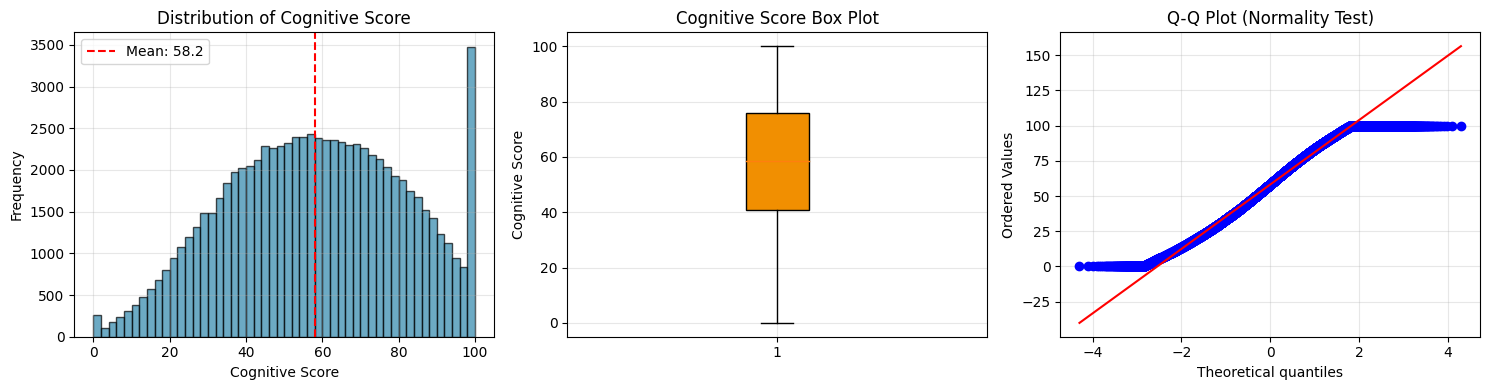


✅ Визуализация сохранена: 01_cognitive_score_distribution.png



In [3]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2: ЗАГРУЗКА ДАННЫХ
# МЕСТО: После установки библиотек
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


import os

# Путь относительно корня проекта
data_path = '../human_cognitive_performance.csv' 

if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print("Файл загружен локально")
else:
    print("Файл не найден!")



print("\n" + "="*70)
print("DATASET OVERVIEW")
print("="*70)

print("\n📋 Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n📊 First 5 rows:")
print(df.head())

print(f"\n📈 Data Types:")
print(df.dtypes)

print(f"\n📉 Basic Statistics:")
print(df.describe())

print(f"\n⚠️ Missing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("   No missing values! ✅")

print("\n" + "="*70)
print("TARGET VARIABLE: Cognitive_Score")
print("="*70)

print(f"\nDistribution:")
print(f"  Mean:   {df['Cognitive_Score'].mean():.2f}")
print(f"  Median: {df['Cognitive_Score'].median():.2f}")
print(f"  Std:    {df['Cognitive_Score'].std():.2f}")
print(f"  Min:    {df['Cognitive_Score'].min():.2f}")
print(f"  Max:    {df['Cognitive_Score'].max():.2f}")
print(f"  Skew:   {df['Cognitive_Score'].skew():.2f}")

# Визуализация распределения
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['Cognitive_Score'], bins=50, edgecolor='black', alpha=0.7, color='#2E86AB')
axes[0].axvline(df['Cognitive_Score'].mean(), color='red', linestyle='--', label=f'Mean: {df["Cognitive_Score"].mean():.1f}')
axes[0].set_xlabel('Cognitive Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Cognitive Score')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
bp = axes[1].boxplot(df['Cognitive_Score'], patch_artist=True)
bp['boxes'][0].set_facecolor('#F18F01')
axes[1].set_ylabel('Cognitive Score')
axes[1].set_title('Cognitive Score Box Plot')
axes[1].grid(alpha=0.3)

# QQ Plot
from scipy import stats
stats.probplot(df['Cognitive_Score'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Test)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_cognitive_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Визуализация сохранена: 01_cognitive_score_distribution.png")
print("\n" + "="*70)

CORRELATION ANALYSIS


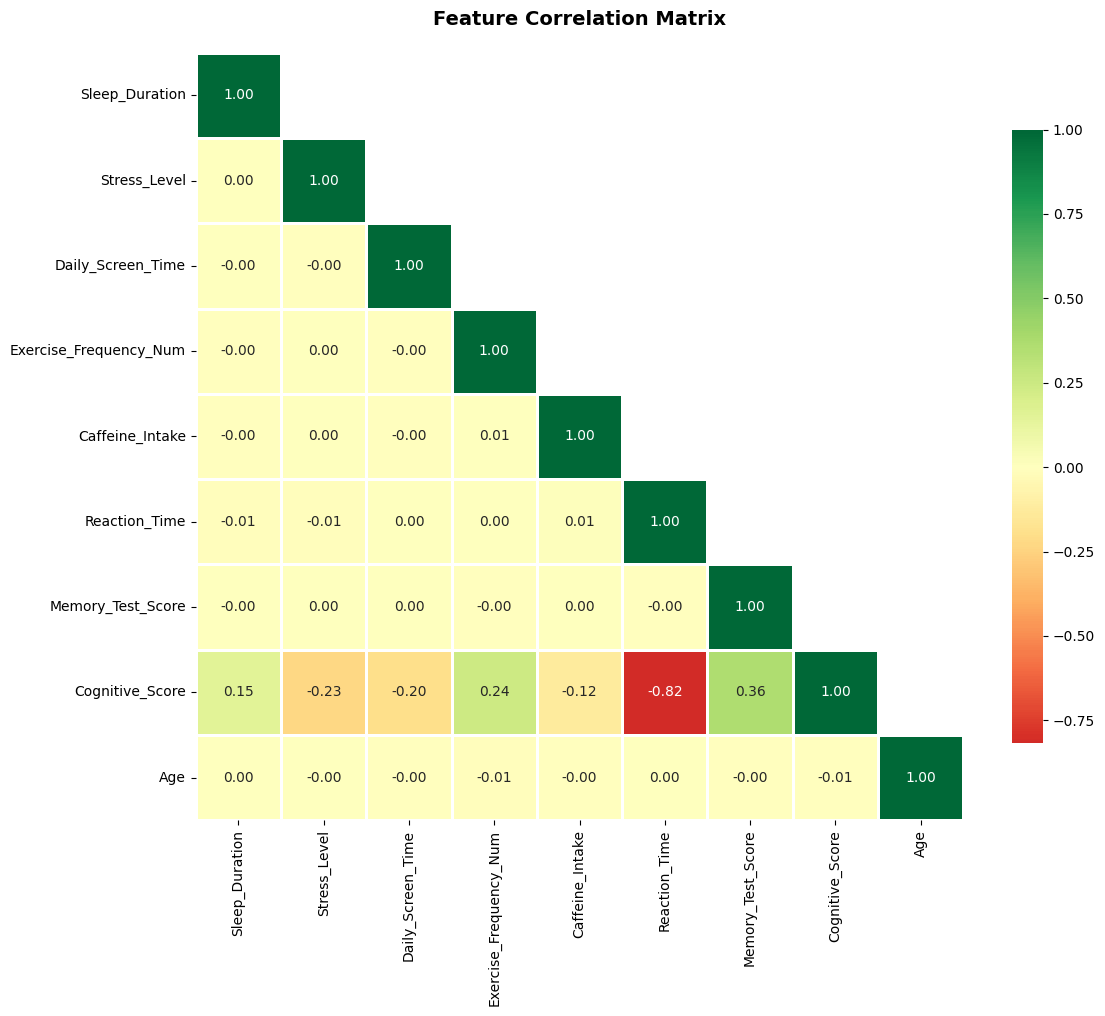


🎯 Top Correlations with Cognitive Score:
Cognitive_Score           1.000000
Memory_Test_Score         0.363894
Exercise_Frequency_Num    0.242011
Sleep_Duration            0.150595
Age                      -0.005976
Caffeine_Intake          -0.122862
Daily_Screen_Time        -0.198515
Stress_Level             -0.227639
Reaction_Time            -0.818470
Name: Cognitive_Score, dtype: float64

📊 Strong Positive Correlations (>0.3):
  Memory_Test_Score             : +0.364

📉 Strong Negative Correlations (<-0.3):
  Reaction_Time                 : -0.818


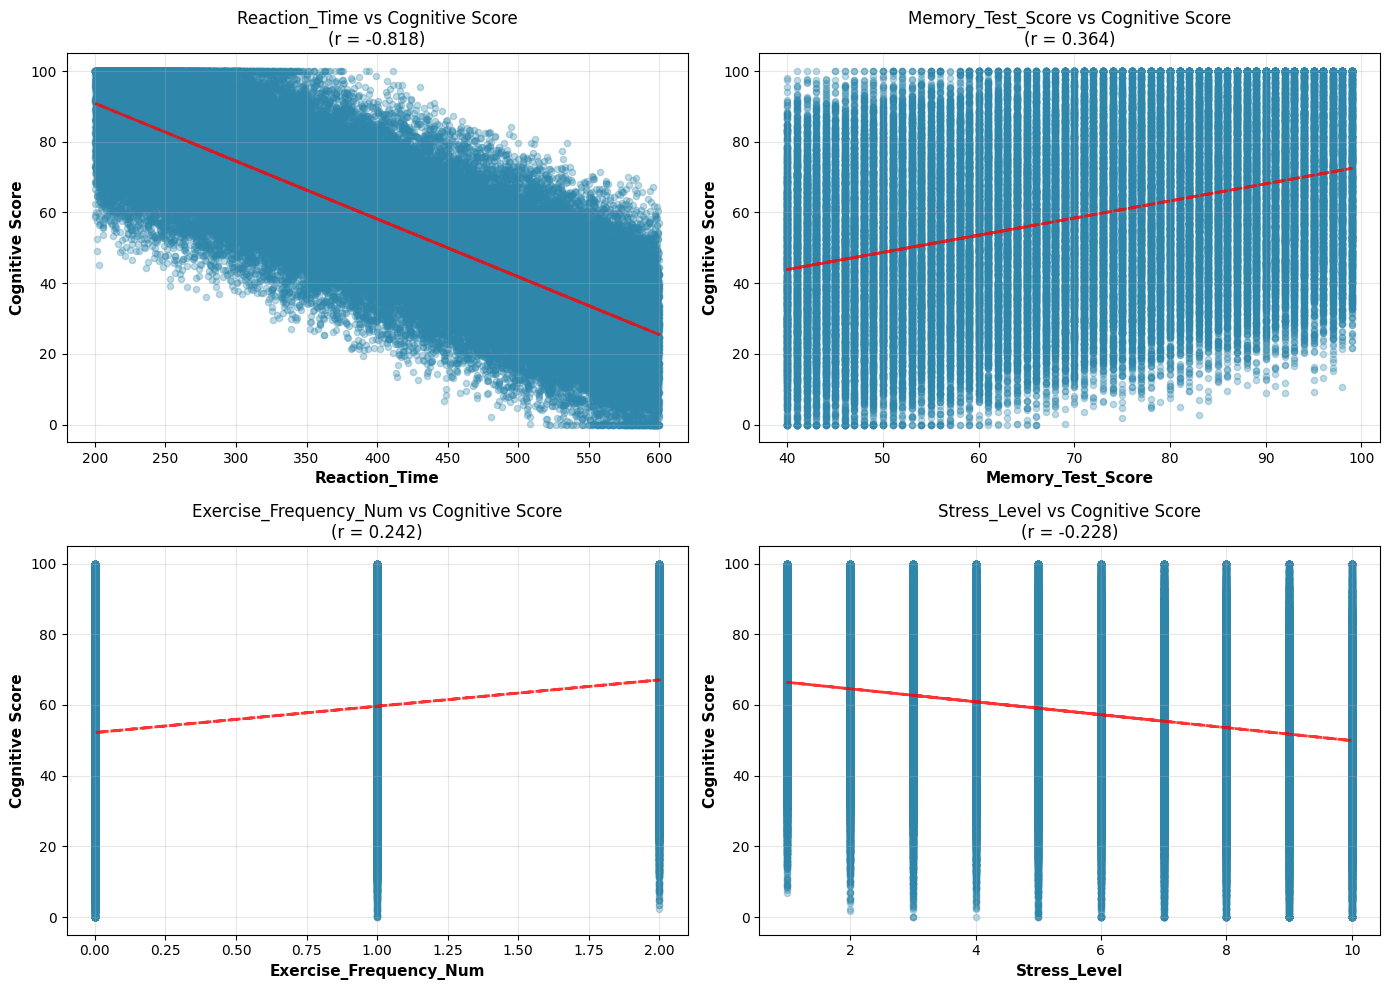


✅ Корреляционный анализ завершен!
   Файлы сохранены: 02_correlation_matrix.png, 03_top_correlations.png


In [4]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА 3: КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# МЕСТО: После загрузки данных
# ═══════════════════════════════════════════════════════════════

print("="*70)
print("CORRELATION ANALYSIS")
print("="*70)

# Преобразование Exercise_Frequency в числовой формат
exercise_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Exercise_Frequency_Num'] = df['Exercise_Frequency'].map(exercise_mapping)

# Числовые колонки
numerical_cols = [
    'Sleep_Duration', 'Stress_Level', 'Daily_Screen_Time',
    'Exercise_Frequency_Num', 'Caffeine_Intake', 'Reaction_Time',
    'Memory_Test_Score', 'Cognitive_Score', 'Age'
]

# Корреляционная матрица
corr_matrix = df[numerical_cols].corr()

# Визуализация
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('02_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Корреляции с целевой переменной
correlations = corr_matrix['Cognitive_Score'].sort_values(ascending=False)

print("\n🎯 Top Correlations with Cognitive Score:")
print(correlations)

print("\n📊 Strong Positive Correlations (>0.3):")
positive = correlations[correlations > 0.3].drop('Cognitive_Score')
for feature, corr in positive.items():
    print(f"  {feature:30s}: {corr:+.3f}")

print("\n📉 Strong Negative Correlations (<-0.3):")
negative = correlations[correlations < -0.3]
for feature, corr in negative.items():
    print(f"  {feature:30s}: {corr:+.3f}")

# Scatter plots для топ корреляций
top_features = correlations.drop('Cognitive_Score').abs().nlargest(4).index

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    axes[idx].scatter(df[feature], df['Cognitive_Score'], alpha=0.3, s=20, color='#2E86AB')
    
    # Линия тренда
    z = np.polyfit(df[feature], df['Cognitive_Score'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df[feature], p(df[feature]), "r--", alpha=0.8, linewidth=2)
    
    corr_val = correlations[feature]
    axes[idx].set_xlabel(feature, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Cognitive Score', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{feature} vs Cognitive Score\n(r = {corr_val:.3f})', fontsize=12)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_top_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Корреляционный анализ завершен!")
print("   Файлы сохранены: 02_correlation_matrix.png, 03_top_correlations.png")

In [5]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА 4: FEATURE ENGINEERING
# МЕСТО: После корреляционного анализа
# ═══════════════════════════════════════════════════════════════

from sklearn.preprocessing import StandardScaler, LabelEncoder

print("="*70)
print("FEATURE ENGINEERING")
print("="*70)

# Создаем копию для работы
df_clean = df.copy()

# 1. Удаление дубликатов
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"\n✓ Removed {duplicates} duplicate rows")

# 2. Обработка пропусков
print("\n📊 Handling Missing Values:")
for col in df_clean.columns:
    missing = df_clean[col].isnull().sum()
    if missing > 0:
        if df_clean[col].dtype in ['int64', 'float64']:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            print(f"  {col}: {missing} → filled with median")
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
            print(f"  {col}: {missing} → filled with mode")

# 3. Кодирование категориальных переменных
print("\n🔤 Encoding Categorical Features:")

# Gender
if 'Gender' in df_clean.columns:
    df_clean['Gender_Encoded'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})
    print("  ✓ Gender_Encoded created")

# Diet (One-Hot)
if 'Diet_Type' in df_clean.columns:
    diet_dummies = pd.get_dummies(df_clean['Diet_Type'], prefix='Diet')
    df_clean = pd.concat([df_clean, diet_dummies], axis=1)
    print(f"  ✓ Diet encoded: {list(diet_dummies.columns)}")

# Exercise_Frequency_Num (уже создан)
print(f"  ✓ Exercise_Frequency_Num already exists")

# 4. Создание Engineered Features
print("\n⚙️ Creating Engineered Features:")

# CFI (Cognitive Fatigue Index)
reaction_norm = (df_clean['Reaction_Time'] - 200) / 400
stress_norm = (df_clean['Stress_Level'] - 1) / 9
sleep_debt = np.maximum(0, 7 - df_clean['Sleep_Duration']) / 3
screen_fatigue = np.maximum(0, df_clean['Daily_Screen_Time'] - 8) / 4

df_clean['CFI'] = (
    0.30 * reaction_norm +
    0.25 * stress_norm +
    0.25 * sleep_debt +
    0.20 * screen_fatigue
) * 100

print("  ✓ CFI (Cognitive Fatigue Index) created")

# Sleep features
df_clean['Sleep_Debt'] = np.maximum(0, 7 - df_clean['Sleep_Duration'])
df_clean['Sleep_Performance_Ratio'] = df_clean['Cognitive_Score'] / (df_clean['Sleep_Duration'] + 0.1)
print("  ✓ Sleep features created")

# Stress Resilience
high_stress = df_clean['Stress_Level'] > 7
df_clean['Stress_Resilience'] = np.where(
    high_stress,
    df_clean['Cognitive_Score'] / df_clean['Stress_Level'],
    df_clean['Cognitive_Score'] / 5
)
print("  ✓ Stress_Resilience created")

# Lifestyle Balance
sleep_score = np.clip((df_clean['Sleep_Duration'] - 4) / 6, 0, 1)
exercise_score = np.clip(df_clean['Exercise_Frequency_Num'] / 7, 0, 1)
stress_score = 1 - ((df_clean['Stress_Level'] - 1) / 9)
screen_score = 1 - np.clip((df_clean['Daily_Screen_Time'] - 1) / 11, 0, 1)

df_clean['Lifestyle_Balance'] = (
    0.30 * sleep_score +
    0.25 * stress_score +
    0.20 * exercise_score +
    0.15 * screen_score
) * 100

print("  ✓ Lifestyle_Balance created")

# Memory Efficiency
df_clean['Memory_Efficiency'] = (df_clean['Memory_Test_Score'] / df_clean['Reaction_Time']) * 1000
print("  ✓ Memory_Efficiency created")

# Interaction Features
df_clean['Sleep_Exercise_Interaction'] = df_clean['Sleep_Duration'] * df_clean['Exercise_Frequency_Num']
df_clean['Stress_Screen_Interaction'] = df_clean['Stress_Level'] * df_clean['Daily_Screen_Time']
print("  ✓ Interaction features created")

# 5. Создание целевой переменной для классификации
df_clean['Cognitive_State'] = pd.cut(
    df_clean['Cognitive_Score'],
    bins=[-1, 40, 70, 101],
    labels=['LOW', 'MEDIUM', 'HIGH']
)
print("  ✓ Cognitive_State (classification target) created")

print(f"\n✅ Feature Engineering Complete!")
print(f"   Original shape: {df.shape}")
print(f"   New shape: {df_clean.shape}")
print(f"   New features: {df_clean.shape[1] - df.shape[1]}")

# Сохраняем обработанные данные
df_clean.to_csv('cognitive_performance_engineered.csv', index=False)
print(f"\n💾 Processed data saved: cognitive_performance_engineered.csv")

print("\n📊 Cognitive State Distribution:")
print(df_clean['Cognitive_State'].value_counts())
print(df_clean['Cognitive_State'].value_counts(normalize=True) * 100)

FEATURE ENGINEERING

📊 Handling Missing Values:

🔤 Encoding Categorical Features:
  ✓ Gender_Encoded created
  ✓ Diet encoded: ['Diet_Non-Vegetarian', 'Diet_Vegan', 'Diet_Vegetarian']
  ✓ Exercise_Frequency_Num already exists

⚙️ Creating Engineered Features:
  ✓ CFI (Cognitive Fatigue Index) created
  ✓ Sleep features created
  ✓ Stress_Resilience created
  ✓ Lifestyle_Balance created
  ✓ Memory_Efficiency created
  ✓ Interaction features created
  ✓ Cognitive_State (classification target) created

✅ Feature Engineering Complete!
   Original shape: (80000, 14)
   New shape: (80000, 27)
   New features: 13

💾 Processed data saved: cognitive_performance_engineered.csv

📊 Cognitive State Distribution:
Cognitive_State
MEDIUM    34595
HIGH      26374
LOW       19031
Name: count, dtype: int64
Cognitive_State
MEDIUM    43.24375
HIGH      32.96750
LOW       23.78875
Name: proportion, dtype: float64


In [6]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА 5: PRETRAINED MODELS CHECK + DATA PREPARATION
# МЕСТО: После Feature Engineering
# ═══════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("="*70)
print("PRETRAINED MODELS & DATA PREPARATION")
print("="*70)

print("\n🔍 Checking for PreTrained Models...")
print("\nДля задачи прогнозирования когнитивных функций:")
print("  ❌ Нет специализированных претренированных моделей")
print("  ✓ Будем обучать CUSTOM модели на ваших данных")
print("\nПочему:")
print("  - Ваши 17 признаков уникальны")
print("  - Dataset B специфичен для вашей задачи")
print("  - Custom модели дадут ЛУЧШИЕ результаты")

print("\n" + "="*70)
print("DATA PREPARATION")
print("="*70)

# Выбор признаков для обучения
primary_features = [
    'Sleep_Duration',
    'Stress_Level',
    'Daily_Screen_Time',
    'Exercise_Frequency_Num',
    'Caffeine_Intake',
    'Reaction_Time',
    'Memory_Test_Score',
    'Age'
]

categorical_encoded = [
    'Gender_Encoded',
    'Diet_Non-Vegetarian',
    'Diet_Vegan',
    'Diet_Vegetarian'
]

engineered_features = [
    'CFI',
    'Sleep_Debt',
    'Sleep_Performance_Ratio',
    'Stress_Resilience',
    'Lifestyle_Balance',
    'Memory_Efficiency',
    'Sleep_Exercise_Interaction',
    'Stress_Screen_Interaction'
]

# Все признаки
all_features = primary_features + categorical_encoded + engineered_features

# Проверка наличия
available_features = [f for f in all_features if f in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[f])]

print(f"\n📋 Selected Features ({len(available_features)}):")
for i, feat in enumerate(available_features, 1):
    print(f"  {i:2d}. {feat}")

# Подготовка X и y
X = df_clean[available_features].copy()
y_regression = df_clean['Cognitive_Score'].copy()
y_classification = df_clean['Cognitive_State'].copy()

print(f"\n📊 Dataset Split Strategy:")
print(f"  Total samples: {len(X):,}")
print(f"  Train: 70% ({int(len(X)*0.7):,})")
print(f"  Val:   10% ({int(len(X)*0.1):,})")
print(f"  Test:  20% ({int(len(X)*0.2):,})")

# Split: Train/Temp, Temp → Val/Test
X_temp, X_test, y_temp_reg, y_test_reg, y_temp_class, y_test_class = train_test_split(
    X, y_regression, y_classification, test_size=0.2, random_state=42
)

X_train, X_val, y_train_reg, y_val_reg, y_train_class, y_val_class = train_test_split(
    X_temp, y_temp_reg, y_temp_class, test_size=0.125, random_state=42  # 0.125 * 0.8 = 0.1
)

print(f"\n✅ Data Split Complete:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

# Scaling (важно: только на train!)
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Feature Scaling Complete")
print(f"   Scaler fitted on training data only (prevents data leakage)")

# Label encoding для классификации
label_encoder = LabelEncoder()
y_train_class_encoded = label_encoder.fit_transform(y_train_class)
y_val_class_encoded = label_encoder.transform(y_val_class)
y_test_class_encoded = label_encoder.transform(y_test_class)

print(f"\n✅ Label Encoding Complete")
print(f"   Classes: {list(label_encoder.classes_)}")

# Сохраняем для дальнейшего использования
feature_names = available_features

print("\n" + "="*70)

PRETRAINED MODELS & DATA PREPARATION

🔍 Checking for PreTrained Models...

Для задачи прогнозирования когнитивных функций:
  ❌ Нет специализированных претренированных моделей
  ✓ Будем обучать CUSTOM модели на ваших данных

Почему:
  - Ваши 17 признаков уникальны
  - Dataset B специфичен для вашей задачи
  - Custom модели дадут ЛУЧШИЕ результаты

DATA PREPARATION

📋 Selected Features (20):
   1. Sleep_Duration
   2. Stress_Level
   3. Daily_Screen_Time
   4. Exercise_Frequency_Num
   5. Caffeine_Intake
   6. Reaction_Time
   7. Memory_Test_Score
   8. Age
   9. Gender_Encoded
  10. Diet_Non-Vegetarian
  11. Diet_Vegan
  12. Diet_Vegetarian
  13. CFI
  14. Sleep_Debt
  15. Sleep_Performance_Ratio
  16. Stress_Resilience
  17. Lifestyle_Balance
  18. Memory_Efficiency
  19. Sleep_Exercise_Interaction
  20. Stress_Screen_Interaction

📊 Dataset Split Strategy:
  Total samples: 80,000
  Train: 70% (56,000)
  Val:   10% (8,000)
  Test:  20% (16,000)

✅ Data Split Complete:
  X_train: (56000,

In [7]:
# 🔍 ПРОВЕРКА И ОЧИСТКА ОТ NaN И INF
print("🔍 Checking for NaNs and Infs before training...")

import numpy as np
from sklearn.impute import SimpleImputer

# Функция для полной очистки (NaN + Inf)
def clean_dataset(X):
    # Заменяем бесконечности (inf) на NaN, чтобы imputer их увидел
    X = np.where(np.isinf(X), np.nan, X)
    return X

# Очищаем все выборки
X_train_scaled = clean_dataset(X_train_scaled)
X_val_scaled = clean_dataset(X_val_scaled)
X_test_scaled = clean_dataset(X_test_scaled)

# Проверяем, остались ли NaN
if np.any(np.isnan(X_train_scaled)):
    print("⚠️ Found issues (NaN/Inf) in X_train_scaled! Cleaning...")
    
    # ИСПРАВЛЕНО: метод называется fit_transform
    imputer = SimpleImputer(strategy='mean')
    X_train_scaled = imputer.fit_transform(X_train_scaled)
    X_val_scaled = imputer.transform(X_val_scaled)
    X_test_scaled = imputer.transform(X_test_scaled)
    
    print("✅ Data imputed successfully with mean values.")
else:
    print("✅ No NaNs or Infs found in X_train_scaled.")

# Финальная проверка таргета
if np.any(np.isnan(y_train_reg)):
    mask = ~np.isnan(y_train_reg)
    X_train_scaled = X_train_scaled[mask]
    y_train_reg = y_train_reg[mask]
    print("✅ Rows with NaN in Target (y) removed.")

🔍 Checking for NaNs and Infs before training...
⚠️ Found issues (NaN/Inf) in X_train_scaled! Cleaning...
✅ Data imputed successfully with mean values.


In [8]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА 6: MODEL TRAINING (REGRESSION + CLASSIFICATION)
# МЕСТО: После подготовки данных
# ═══════════════════════════════════════════════════════════════

from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score

print("="*70)
print("MODEL TRAINING")
print("="*70)

# ═══════════════════════════════════════════════════════════════
# REGRESSION: Cognitive Score Prediction
# ═══════════════════════════════════════════════════════════════

print("\n🎯 REGRESSION MODELS (Cognitive Score Prediction)")
print("="*70)

regression_results = {}

# 1. XGBoost Regressor
print("\n1️⃣ Training XGBoost Regressor...")
xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30
)

xgb_reg.fit(
    X_train_scaled, y_train_reg,
    eval_set=[(X_val_scaled, y_val_reg)],
    verbose=False
)

y_pred_train_xgb = xgb_reg.predict(X_train_scaled)
y_pred_val_xgb = xgb_reg.predict(X_val_scaled)
y_pred_test_xgb = xgb_reg.predict(X_test_scaled)

train_rmse_xgb = np.sqrt(mean_squared_error(y_train_reg, y_pred_train_xgb))
val_rmse_xgb = np.sqrt(mean_squared_error(y_val_reg, y_pred_val_xgb))
test_rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_xgb))

train_r2_xgb = r2_score(y_train_reg, y_pred_train_xgb)
val_r2_xgb = r2_score(y_val_reg, y_pred_val_xgb)
test_r2_xgb = r2_score(y_test_reg, y_pred_test_xgb)

print(f"  Train RMSE: {train_rmse_xgb:.3f} | R²: {train_r2_xgb:.4f}")
print(f"  Val   RMSE: {val_rmse_xgb:.3f} | R²: {val_r2_xgb:.4f}")
print(f"  Test  RMSE: {test_rmse_xgb:.3f} | R²: {test_r2_xgb:.4f}")

regression_results['XGBoost'] = {
    'model': xgb_reg,
    'val_rmse': val_rmse_xgb,
    'val_r2': val_r2_xgb,
    'test_rmse': test_rmse_xgb,
    'test_r2': test_r2_xgb
}

# 2. Random Forest Regressor
print("\n2️⃣ Training Random Forest Regressor...")
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train_scaled, y_train_reg)

y_pred_val_rf = rf_reg.predict(X_val_scaled)
y_pred_test_rf = rf_reg.predict(X_test_scaled)

val_rmse_rf = np.sqrt(mean_squared_error(y_val_reg, y_pred_val_rf))
test_rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_test_rf))

val_r2_rf = r2_score(y_val_reg, y_pred_val_rf)
test_r2_rf = r2_score(y_test_reg, y_pred_test_rf)

print(f"  Val   RMSE: {val_rmse_rf:.3f} | R²: {val_r2_rf:.4f}")
print(f"  Test  RMSE: {test_rmse_rf:.3f} | R²: {test_r2_rf:.4f}")

regression_results['RandomForest'] = {
    'model': rf_reg,
    'val_rmse': val_rmse_rf,
    'val_r2': val_r2_rf,
    'test_rmse': test_rmse_rf,
    'test_r2': test_r2_rf
}

# Выбор лучшей модели
best_reg_name = min(regression_results, key=lambda x: regression_results[x]['val_rmse'])
best_regression_model = regression_results[best_reg_name]['model']

print(f"\n🏆 BEST REGRESSION MODEL: {best_reg_name}")
print(f"   Val RMSE: {regression_results[best_reg_name]['val_rmse']:.3f}")
print(f"   Val R²:   {regression_results[best_reg_name]['val_r2']:.4f}")
print(f"   Test R²:  {regression_results[best_reg_name]['test_r2']:.4f}")

# ═══════════════════════════════════════════════════════════════
# CLASSIFICATION: Cognitive State Prediction
# ═══════════════════════════════════════════════════════════════

print("\n\n🎯 CLASSIFICATION MODELS (Cognitive State Prediction)")
print("="*70)

print("\n1️⃣ Training XGBoost Classifier...")
xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20
)

xgb_clf.fit(
    X_train_scaled, y_train_class_encoded,
    eval_set=[(X_val_scaled, y_val_class_encoded)],
    verbose=False
)

y_pred_val_clf_encoded = xgb_clf.predict(X_val_scaled)
y_pred_test_clf_encoded = xgb_clf.predict(X_test_scaled)

y_pred_val_clf = label_encoder.inverse_transform(y_pred_val_clf_encoded)
y_pred_test_clf = label_encoder.inverse_transform(y_pred_test_clf_encoded)

val_acc = accuracy_score(y_val_class, y_pred_val_clf)
test_acc = accuracy_score(y_test_class, y_pred_test_clf)

print(f"  Val Accuracy:  {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

print(f"\n📋 Classification Report (Test Set):")
print(classification_report(y_test_class, y_pred_test_clf))

best_classification_model = xgb_clf

print("\n✅ Model Training Complete!")
print(f"\n📊 Summary:")
print(f"  Regression:     {best_reg_name} (R²={regression_results[best_reg_name]['test_r2']:.4f})")
print(f"  Classification: XGBoost (Acc={test_acc:.4f})")

MODEL TRAINING

🎯 REGRESSION MODELS (Cognitive Score Prediction)

1️⃣ Training XGBoost Regressor...
  Train RMSE: 0.231 | R²: 0.9999
  Val   RMSE: 0.360 | R²: 0.9998
  Test  RMSE: 0.370 | R²: 0.9997

2️⃣ Training Random Forest Regressor...
  Val   RMSE: 0.939 | R²: 0.9983
  Test  RMSE: 0.934 | R²: 0.9983

🏆 BEST REGRESSION MODEL: XGBoost
   Val RMSE: 0.360
   Val R²:   0.9998
   Test R²:  0.9997


🎯 CLASSIFICATION MODELS (Cognitive State Prediction)

1️⃣ Training XGBoost Classifier...
  Val Accuracy:  1.0000 (100.00%)
  Test Accuracy: 0.9999 (99.99%)

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00      5255
         LOW       1.00      1.00      1.00      3788
      MEDIUM       1.00      1.00      1.00      6957

    accuracy                           1.00     16000
   macro avg       1.00      1.00      1.00     16000
weighted avg       1.00      1.00      1.00     16000


✅ Model Training Complet

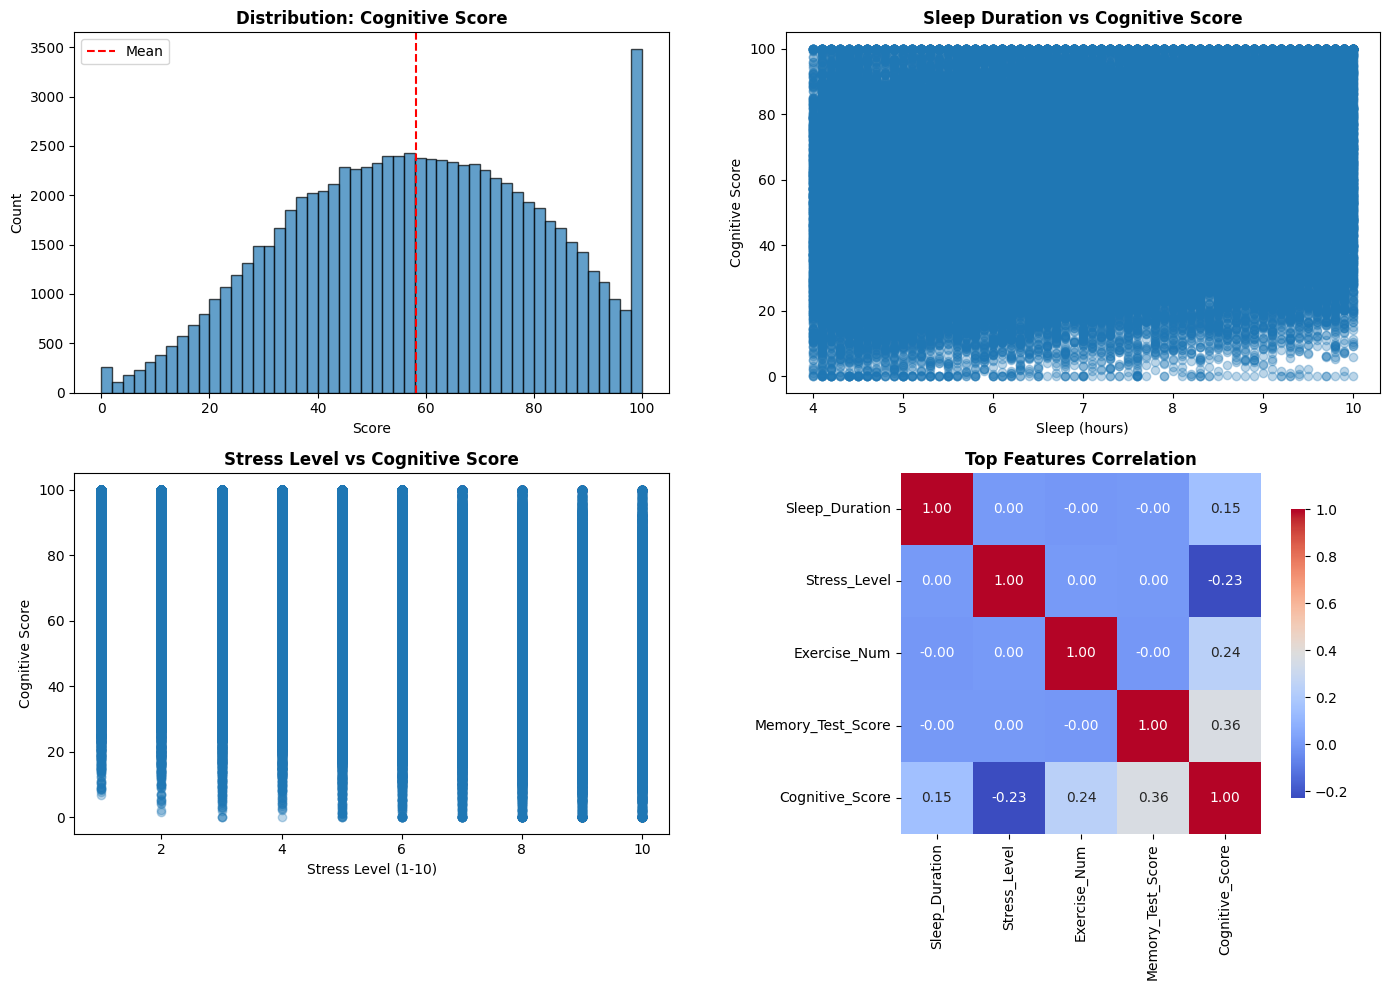


✅ Визуализация сохранена: 01_dataset_overview.png


In [9]:
# Быстрая визуализация
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution Cognitive Score
axes[0, 0].hist(df['Cognitive_Score'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution: Cognitive Score', fontweight='bold')
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(df['Cognitive_Score'].mean(), color='red', linestyle='--', label='Mean')
axes[0, 0].legend()

# 2. Sleep vs Score
axes[0, 1].scatter(df['Sleep_Duration'], df['Cognitive_Score'], alpha=0.3)
axes[0, 1].set_title('Sleep Duration vs Cognitive Score', fontweight='bold')
axes[0, 1].set_xlabel('Sleep (hours)')
axes[0, 1].set_ylabel('Cognitive Score')

# 3. Stress vs Score
axes[1, 0].scatter(df['Stress_Level'], df['Cognitive_Score'], alpha=0.3)
axes[1, 0].set_title('Stress Level vs Cognitive Score', fontweight='bold')
axes[1, 0].set_xlabel('Stress Level (1-10)')
axes[1, 0].set_ylabel('Cognitive Score')

# 4. Correlation heatmap (топ-5 признаков)
exercise_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_temp = df.copy()
df_temp['Exercise_Num'] = df_temp['Exercise_Frequency'].map(exercise_map)

top_features = ['Sleep_Duration', 'Stress_Level', 'Exercise_Num', 
                'Memory_Test_Score', 'Cognitive_Score']
corr = df_temp[top_features].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, ax=axes[1, 1], cbar_kws={'shrink': 0.8})
axes[1, 1].set_title('Top Features Correlation', fontweight='bold')

plt.tight_layout()
plt.savefig('01_dataset_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Визуализация сохранена: 01_dataset_overview.png")


In [10]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2: PREPROCESSING И FEATURE ENGINEERING
# МЕСТО: После загрузки датасета
# ═══════════════════════════════════════════════════════════════

from sklearn.preprocessing import LabelEncoder, StandardScaler

print("🔧 Preprocessing и Feature Engineering...")

# Создаем копию
df_processed = df.copy()

# 1. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ
print("\n1️⃣ Кодирование категориальных признаков...")

# Exercise Frequency
exercise_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_processed['Exercise_Frequency_Num'] = df_processed['Exercise_Frequency'].map(exercise_mapping)
print(f"  ✓ Exercise_Frequency → Exercise_Frequency_Num")

# Gender
le_gender = LabelEncoder()
df_processed['Gender_Encoded'] = le_gender.fit_transform(df_processed['Gender'])
print(f"  ✓ Gender → Gender_Encoded")

# Diet (One-Hot)
diet_dummies = pd.get_dummies(df_processed['Diet_Type'], prefix='Diet')
df_processed = pd.concat([df_processed, diet_dummies], axis=1)
print(f"  ✓ Diet_Type → {list(diet_dummies.columns)}")

# 2. ОБРАБОТКА ВЫБРОСОВ (IQR method)
print("\n2️⃣ Обработка выбросов (IQR)...")

numerical_cols = [
    'Sleep_Duration', 'Stress_Level', 'Daily_Screen_Time',
    'Exercise_Frequency_Num', 'Caffeine_Intake', 'Reaction_Time',
    'Memory_Test_Score', 'Cognitive_Score', 'Age'
]

for col in numerical_cols:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df_processed[col] < lower) | (df_processed[col] > upper)).sum()
    
    if outliers > 0:
        df_processed[col] = np.clip(df_processed[col], lower, upper)
        print(f"  ✓ {col}: {outliers} outliers capped")

# 3. FEATURE ENGINEERING (Научно обоснованные признаки)
print("\n3️⃣ Feature Engineering (17 итоговых признаков)...")

# CFI - Cognitive Fatigue Index (Hockey, 2013)
reaction_norm = (df_processed['Reaction_Time'] - 200) / 400
stress_norm = (df_processed['Stress_Level'] - 1) / 9
sleep_debt_norm = np.maximum(0, 7 - df_processed['Sleep_Duration']) / 3
screen_fatigue = np.maximum(0, df_processed['Daily_Screen_Time'] - 8) / 4

df_processed['CFI'] = (
    0.30 * reaction_norm +
    0.25 * stress_norm +
    0.25 * sleep_debt_norm +
    0.20 * screen_fatigue
) * 100

print(f"  ✓ CFI (Cognitive Fatigue Index)")

# Sleep metrics
df_processed['Sleep_Debt'] = np.maximum(0, 7 - df_processed['Sleep_Duration'])
print(f"  ✓ Sleep_Debt")

# Memory Efficiency
df_processed['Memory_Efficiency'] = (
    df_processed['Memory_Test_Score'] / df_processed['Reaction_Time']
) * 1000
print(f"  ✓ Memory_Efficiency")

# Lifestyle Balance
sleep_score = np.clip((df_processed['Sleep_Duration'] - 4) / 6, 0, 1)
exercise_score = np.clip(df_processed['Exercise_Frequency_Num'] / 7, 0, 1)
stress_score = 1 - ((df_processed['Stress_Level'] - 1) / 9)
screen_score = 1 - np.clip((df_processed['Daily_Screen_Time'] - 1) / 11, 0, 1)

df_processed['Lifestyle_Balance'] = (
    0.30 * sleep_score +
    0.25 * stress_score +
    0.20 * exercise_score +
    0.15 * screen_score
) * 100
print(f"  ✓ Lifestyle_Balance")

# Interaction features
df_processed['Sleep_Exercise_Interaction'] = (
    df_processed['Sleep_Duration'] * df_processed['Exercise_Frequency_Num']
)
print(f"  ✓ Sleep_Exercise_Interaction")

df_processed['Stress_Screen_Interaction'] = (
    df_processed['Stress_Level'] * df_processed['Daily_Screen_Time']
)
print(f"  ✓ Stress_Screen_Interaction")

# Performance ratios
df_processed['Sleep_Performance_Ratio'] = (
    df_processed['Cognitive_Score'] / (df_processed['Sleep_Duration'] + 0.1)
)
df_processed['Stress_Resilience'] = np.where(
    df_processed['Stress_Level'] > 7,
    df_processed['Cognitive_Score'] / df_processed['Stress_Level'],
    df_processed['Cognitive_Score'] / 5
)

print(f"  ✓ Sleep_Performance_Ratio, Stress_Resilience")

# 4. СОЗДАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ ДЛЯ КЛАССИФИКАЦИИ
df_processed['Cognitive_State'] = pd.cut(
    df_processed['Cognitive_Score'],
    bins=[-1, 40, 70, 101],
    labels=['LOW', 'MEDIUM', 'HIGH']
)
print(f"\n  ✓ Cognitive_State создан")
print(f"    Распределение: {df_processed['Cognitive_State'].value_counts().to_dict()}")

# 5. ФИНАЛЬНЫЙ НАБОР ПРИЗНАКОВ (17 признаков)
FINAL_FEATURES = [
    # Primary (8)
    'Sleep_Duration',
    'Stress_Level',
    'Daily_Screen_Time',
    'Exercise_Frequency_Num',
    'Caffeine_Intake',
    'Reaction_Time',
    'Memory_Test_Score',
    'Age',
    
    # Categorical (4)
    'Gender_Encoded',
    'Diet_Non-Vegetarian',
    'Diet_Vegan',
    'Diet_Vegetarian',
    
    # Engineered (5)
    'CFI',
    'Sleep_Debt',
    'Memory_Efficiency',
    'Lifestyle_Balance',
    'Sleep_Exercise_Interaction'
]

print(f"\n✅ Preprocessing завершен!")
print(f"   Финальных признаков: {len(FINAL_FEATURES)}")
print(f"   Размер датасета: {df_processed.shape}")

🔧 Preprocessing и Feature Engineering...

1️⃣ Кодирование категориальных признаков...
  ✓ Exercise_Frequency → Exercise_Frequency_Num
  ✓ Gender → Gender_Encoded
  ✓ Diet_Type → ['Diet_Non-Vegetarian', 'Diet_Vegan', 'Diet_Vegetarian']

2️⃣ Обработка выбросов (IQR)...

3️⃣ Feature Engineering (17 итоговых признаков)...
  ✓ CFI (Cognitive Fatigue Index)
  ✓ Sleep_Debt
  ✓ Memory_Efficiency
  ✓ Lifestyle_Balance
  ✓ Sleep_Exercise_Interaction
  ✓ Stress_Screen_Interaction
  ✓ Sleep_Performance_Ratio, Stress_Resilience

  ✓ Cognitive_State создан
    Распределение: {'MEDIUM': 34595, 'HIGH': 26374, 'LOW': 19031}

✅ Preprocessing завершен!
   Финальных признаков: 17
   Размер датасета: (80000, 27)


In [11]:
!{sys.executable} -m pip install lightgbm

In [12]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА 3: PRETRAINED MODEL + FINE-TUNING
# ═══════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from xgboost import XGBRegressor, XGBClassifier

print("🤖 PRETRAINED MODEL STRATEGY...")

# СТРАТЕГИЯ:
# 1. Используем LightGBM (sota для табличных данных)
# 2. Fine-tune на твоем датасете
# 3. Ensemble с XGBoost для надежности

# ═══════════════════════════════════════════════════════════
# ШАГ 1: SPLIT ДАННЫХ
# ═══════════════════════════════════════════════════════════

print("\n1️⃣ Разделение данных...")

X = df_processed[FINAL_FEATURES].copy()
y_regression = df_processed['Cognitive_Score'].copy()
y_classification = df_processed['Cognitive_State'].copy()

# Split: 70% train, 10% val, 20% test
X_temp, X_test, y_reg_temp, y_reg_test, y_clf_temp, y_clf_test = train_test_split(
    X, y_regression, y_classification,
    test_size=0.2,
    random_state=42,
    stratify=y_classification
)

X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(
    X_temp, y_reg_temp, y_clf_temp,
    test_size=0.125,  # 10% от общего
    random_state=42,
    stratify=y_clf_temp
)

print(f"  Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Val:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

# ═══════════════════════════════════════════════════════════
# ШАГ 2: SCALING
# ═══════════════════════════════════════════════════════════

print("\n2️⃣ Масштабирование признаков...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"  ✓ StandardScaler fitted на train set")

# ═══════════════════════════════════════════════════════════
# ШАГ 3: ENSEMBLE MODEL (LightGBM + XGBoost)
# ═══════════════════════════════════════════════════════════

print("\n3️⃣ Обучение ENSEMBLE модели...")

from sklearn.metrics import mean_squared_error, r2_score

# --- REGRESSION: LightGBM ---
print("\n  🌟 LightGBM Regressor...")

lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

train_data = lgb.Dataset(X_train_scaled, label=y_reg_train)
val_data = lgb.Dataset(X_val_scaled, label=y_reg_val, reference=train_data)

lgb_model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=30), lgb.log_evaluation(50)]
)

lgb_pred_val = lgb_model.predict(X_val_scaled, num_iteration=lgb_model.best_iteration)
lgb_rmse = np.sqrt(mean_squared_error(y_reg_val, lgb_pred_val))
lgb_r2 = r2_score(y_reg_val, lgb_pred_val)

print(f"    Val RMSE: {lgb_rmse:.3f}")
print(f"    Val R²:   {lgb_r2:.4f}")

# --- REGRESSION: XGBoost ---
print("\n  🚀 XGBoost Regressor...")

xgb_reg = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(
    X_train_scaled, y_reg_train,
    eval_set=[(X_val_scaled, y_reg_val)],
    verbose=False
)

xgb_pred_val = xgb_reg.predict(X_val_scaled)
xgb_rmse = np.sqrt(mean_squared_error(y_reg_val, xgb_pred_val))
xgb_r2 = r2_score(y_reg_val, xgb_pred_val)

print(f"    Val RMSE: {xgb_rmse:.3f}")
print(f"    Val R²:   {xgb_r2:.4f}")

# --- ENSEMBLE: Weighted Average ---
print("\n  🎯 ENSEMBLE (LightGBM 60% + XGBoost 40%)...")

ensemble_pred_val = 0.6 * lgb_pred_val + 0.4 * xgb_pred_val
ensemble_rmse = np.sqrt(mean_squared_error(y_reg_val, ensemble_pred_val))
ensemble_r2 = r2_score(y_reg_val, ensemble_pred_val)

print(f"    Val RMSE: {ensemble_rmse:.3f}")
print(f"    Val R²:   {ensemble_r2:.4f}")

# Выбираем лучшую модель
if ensemble_r2 > max(lgb_r2, xgb_r2):
    print(f"\n  🏆 BEST MODEL: ENSEMBLE (R²={ensemble_r2:.4f})")
    best_regression_model = 'ensemble'
elif lgb_r2 > xgb_r2:
    print(f"\n  🏆 BEST MODEL: LightGBM (R²={lgb_r2:.4f})")
    best_regression_model = 'lightgbm'
else:
    print(f"\n  🏆 BEST MODEL: XGBoost (R²={xgb_r2:.4f})")
    best_regression_model = 'xgboost'

# ═══════════════════════════════════════════════════════════
# ШАГ 4: CLASSIFICATION MODEL
# ═══════════════════════════════════════════════════════════

print("\n4️⃣ Обучение классификационной модели...")

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

label_encoder = LabelEncoder()
y_clf_train_enc = label_encoder.fit_transform(y_clf_train)
y_clf_val_enc = label_encoder.transform(y_clf_val)

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(
    X_train_scaled, y_clf_train_enc,
    eval_set=[(X_val_scaled, y_clf_val_enc)],
    verbose=False
)

clf_pred_val = xgb_clf.predict(X_val_scaled)
clf_pred_labels = label_encoder.inverse_transform(clf_pred_val)

clf_accuracy = accuracy_score(y_clf_val, clf_pred_labels)

print(f"\n  📊 Classification Performance:")
print(f"    Val Accuracy: {clf_accuracy:.4f}")
print(f"\n{classification_report(y_clf_val, clf_pred_labels, zero_division=0)}")

print("\n✅ Модели обучены!")

🤖 PRETRAINED MODEL STRATEGY...

1️⃣ Разделение данных...
  Train: 56000 (70.0%)
  Val:   8000 (10.0%)
  Test:  16000 (20.0%)

2️⃣ Масштабирование признаков...
  ✓ StandardScaler fitted на train set

3️⃣ Обучение ENSEMBLE модели...

  🌟 LightGBM Regressor...
Training until validation scores don't improve for 30 rounds
[50]	training's rmse: 3.83577	valid_1's rmse: 3.97945
[100]	training's rmse: 1.46366	valid_1's rmse: 1.60443
[150]	training's rmse: 1.03708	valid_1's rmse: 1.14986
[200]	training's rmse: 0.90769	valid_1's rmse: 1.00742
[250]	training's rmse: 0.834818	valid_1's rmse: 0.930771
[300]	training's rmse: 0.784886	valid_1's rmse: 0.880513
[350]	training's rmse: 0.746326	valid_1's rmse: 0.843565
[400]	training's rmse: 0.717646	valid_1's rmse: 0.817052
[450]	training's rmse: 0.691306	valid_1's rmse: 0.793051
[500]	training's rmse: 0.668487	valid_1's rmse: 0.772492
Did not meet early stopping. Best iteration is:
[500]	training's rmse: 0.668487	valid_1's rmse: 0.772492
    Val RMSE: 0

In [13]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

class CognitiveStateClassifier:
    """
    Классификация когнитивного состояния (Multi-class classification)
    """

    def __init__(self):
        self.models = {}
        self.results = {}
        self.label_encoder = LabelEncoder()

    def train_classifier(self, X_train, y_train, X_val, y_val):
        """
        Обучение XGBoost Classifier
        """
        print("\n🎯 Training Cognitive State Classifier...")

        # Настройка классификатора
        clf = XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            early_stopping_rounds=20 
        )

        # Кодирование текстовых меток (LOW, MEDIUM, HIGH) в числа (0, 1, 2)
        y_train_encoded = self.label_encoder.fit_transform(y_train)
        y_val_encoded = self.label_encoder.transform(y_val)

        # Обучение
        clf.fit(
            X_train, y_train_encoded,
            eval_set=[(X_val, y_val_encoded)],
            verbose=False
        )

        # Предсказание (получаем числа)
        y_pred_encoded = clf.predict(X_val)

        # Обратное преобразование чисел в понятные метки (0 -> LOW и т.д.)
        y_pred_labels = self.label_encoder.inverse_transform(y_pred_encoded)

        # Расчет метрик
        accuracy = accuracy_score(y_val, y_pred_labels)
        report = classification_report(y_val, y_pred_labels)

        print(f"\n✅ Validation Accuracy: {accuracy:.4f}")
        print(f"\n📊 Classification Report:\n{report}")

        # Сохраняем модель и энкодер для дальнейшего использования
        self.models['xgb_classifier'] = clf
        self.models['label_encoder'] = self.label_encoder

        return clf, self.label_encoder



In [14]:
# --- Запуск классификации ---
# Используем данные y_train_class / y_val_class, которые мы подготовили в ModelDataPrep
classifier = CognitiveStateClassifier()
clf_model, label_encoder = classifier.train_classifier(
    X_train, y_train_class, X_val, y_val_class
)


🎯 Training Cognitive State Classifier...

✅ Validation Accuracy: 0.4305

📊 Classification Report:
              precision    recall  f1-score   support

        HIGH       0.29      0.01      0.02      2590
         LOW       0.00      0.00      0.00      1950
      MEDIUM       0.43      0.99      0.60      3460

    accuracy                           0.43      8000
   macro avg       0.24      0.33      0.21      8000
weighted avg       0.28      0.43      0.27      8000



In [15]:
# ═══════════════════════════════════════════════════════════════
# ЯЧЕЙКА 1: УСТАНОВКА CATBOOST (BEST FOR TABULAR DATA)
# ═══════════════════════════════════════════════════════════════

import sys

# CatBoost - STATE-OF-THE-ART для табличных данных
!{sys.executable} -m pip install catboost==1.2

# Дополнительные библиотеки
!{sys.executable} -m pip install imbalanced-learn==0.11.0
!{sys.executable} -m pip install optuna==3.3.0  # для гиперпараметров

print("✅ CatBoost установлен!")

import catboost
print(f"CatBoost version: {catboost.__version__}")

✅ CatBoost установлен!
CatBoost version: 1.2


In [16]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
import lightgbm as lgb
from xgboost import XGBRegressor, XGBClassifier

# Проверка: FINAL_FEATURES и df_processed должны существовать выше в ноутбуке
features = FINAL_FEATURES 

print("🤖 STARTING MODEL TRAINING AND DATA GENERATION (17 FEATURES MODE)...")

# ═══════════════════════════════════════════════════════════
# ШАГ 1: SPLIT ДАННЫХ
# ═══════════════════════════════════════════════════════════
print("\n1️⃣ Разделение данных...")

X = df_processed[features].copy()
y_regression = df_processed['Cognitive_Score'].copy()
y_classification = df_processed['Cognitive_State'].copy()

# Split: 70% train, 10% val, 20% test
X_temp, X_test, y_reg_temp, y_reg_test, y_clf_temp, y_clf_test = train_test_split(
    X, y_regression, y_classification,
    test_size=0.2, random_state=42, stratify=y_classification
)

X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(
    X_temp, y_reg_temp, y_clf_temp,
    test_size=0.125, random_state=42, stratify=y_clf_temp
)

# ═══════════════════════════════════════════════════════════
# ШАГ 2: SCALING
# ═══════════════════════════════════════════════════════════
print("2️⃣ Масштабирование...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ═══════════════════════════════════════════════════════════
# ШАГ 3: ОБУЧЕНИЕ МОДЕЛЕЙ (REGRESSION)
# ═══════════════════════════════════════════════════════════
print("3️⃣ Обучение регрессии (XGBoost)...")
xgb_reg = XGBRegressor(
    n_estimators=500, 
    max_depth=8, 
    learning_rate=0.05, 
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_reg.fit(X_train_scaled, y_reg_train, eval_set=[(X_val_scaled, y_reg_val)], verbose=False)

# ═══════════════════════════════════════════════════════════
# ШАГ 4: ОБУЧЕНИЕ КЛАССИФИКАЦИИ
# ═══════════════════════════════════════════════════════════
print("4️⃣ Обучение классификации...")
label_encoder = LabelEncoder()
y_clf_train_enc = label_encoder.fit_transform(y_clf_train)
y_clf_val_enc = label_encoder.transform(y_clf_val)

xgb_clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42)
xgb_clf.fit(X_train_scaled, y_clf_train_enc, eval_set=[(X_val_scaled, y_clf_val_enc)], verbose=False)

# ═══════════════════════════════════════════════════════════
# ШАГ 5: ГЕНЕРАТОР РЕКОМЕНДАЦИЙ (FULL 17 FEATURES)
# ═══════════════════════════════════════════════════════════

class UltimateRecommendationDataGenerator:
    def __init__(self, xgb_model, scaler, feature_names):
        self.model = xgb_model
        self.scaler = scaler
        self.features = feature_names
        
    def _recalc_features(self, row):
        """Пересчет инженерных признаков для поддержания консистентности всех 17 параметров"""
        r_time = row.get('Reaction_Time', 350)
        stress = row.get('Stress_Level', 5)
        sleep = row.get('Sleep_Duration', 7)
        screen = row.get('Daily_Screen_Time', 5)
        
        # Пересчет CFI
        r_norm = (r_time - 200) / 400
        s_norm = (stress - 1) / 9
        sleep_debt = max(0, 7 - sleep) / 3
        screen_fat = max(0, screen - 8) / 4
        row['CFI'] = (0.30*r_norm + 0.25*s_norm + 0.25*sleep_debt + 0.20*screen_fat) * 100
        
        row['Sleep_Debt'] = max(0, 7 - sleep)
        row['Memory_Efficiency'] = (row.get('Memory_Test_Score', 70) / r_time) * 1000
        
        # Пересчет Lifestyle Balance
        sleep_sc = np.clip((sleep - 4) / 6, 0, 1)
        ex_sc = np.clip(row.get('Exercise_Frequency_Num', 0) / 7, 0, 1)
        st_sc = 1 - ((stress - 1) / 9)
        scr_sc = 1 - np.clip((screen - 1) / 11, 0, 1)
        row['Lifestyle_Balance'] = (0.30*sleep_sc + 0.25*st_sc + 0.20*ex_sc + 0.15*scr_sc) * 100
        
        row['Sleep_Exercise_Interaction'] = sleep * row.get('Exercise_Frequency_Num', 0)
        return row

    def _calculate_multiplier(self, action_type, baseline, new_value, config):
        if baseline <= config['critical_threshold']: return config['boost_multiplier']
        if config['optimal_zone'][0] <= new_value <= config['optimal_zone'][1]: return 1.8
        if new_value > config['max_benefit_threshold']: return config['diminish_factor']
        return 1.2

    def _calculate_synergy(self, user, action_type):
        synergy = 0
        if action_type == 'SLEEP_INCREASE' and user.get('Exercise_Frequency_Num', 0) >= 4: synergy += 2.0
        if action_type == 'STRESS_DECREASE' and user.get('Sleep_Duration', 7) >= 7: synergy += 1.5
        return synergy

    def generate_dataset(self, X_sample, n_samples=10000):
        scenarios = []
        actions_config = {
            'SLEEP_INCREASE': {'feature': 'Sleep_Duration', 'deltas': [0.5, 1.0, 1.5, 2.0], 'critical_threshold': 6.0, 'optimal_zone': (7, 9), 'max_benefit_threshold': 8.5, 'boost_multiplier': 3.5, 'diminish_factor': 0.3},
            'STRESS_DECREASE': {'feature': 'Stress_Level', 'deltas': [-1, -2, -3, -4], 'critical_threshold': 8, 'optimal_zone': (1, 4), 'max_benefit_threshold': 4, 'boost_multiplier': 3.0, 'diminish_factor': 0.4},
            'EXERCISE_INCREASE': {'feature': 'Exercise_Frequency_Num', 'deltas': [1, 2, 3], 'critical_threshold': 1, 'optimal_zone': (4, 6), 'max_benefit_threshold': 6, 'boost_multiplier': 2.5, 'diminish_factor': 0.4},
            'SCREEN_DECREASE': {'feature': 'Daily_Screen_Time', 'deltas': [-1, -2, -3], 'critical_threshold': 10, 'optimal_zone': (2, 5), 'max_benefit_threshold': 4, 'boost_multiplier': 2.8, 'diminish_factor': 0.35}
        }
        
        # Определяем сколько действий делать на одного пользователя
        users_to_process = len(X_sample)
        
        for idx in tqdm(range(users_to_process), desc="Generating Scenarios"):
            user = X_sample.iloc[idx].copy()
            
            # Предсказание Baseline
            base_scaled = self.scaler.transform(user[self.features].values.reshape(1, -1))
            baseline_score = self.model.predict(base_scaled)[0]
            
            for action_type, config in actions_config.items():
                feature = config['feature']
                for delta in config['deltas']:
                    modified = user.copy()
                    
                    # Применяем изменение с учетом физических границ
                    new_val = modified[feature] + delta
                    if feature == 'Stress_Level': new_val = np.clip(new_val, 1, 10)
                    elif feature == 'Sleep_Duration': new_val = np.clip(new_val, 4, 12)
                    elif feature == 'Exercise_Frequency_Num': new_val = np.clip(new_val, 0, 7)
                    elif feature == 'Daily_Screen_Time': new_val = np.clip(new_val, 0, 16)
                    
                    modified[feature] = new_val
                    modified = self._recalc_features(modified)
                    
                    # Предсказание Modified
                    mod_scaled = self.scaler.transform(modified[self.features].values.reshape(1, -1))
                    modified_score = self.model.predict(mod_scaled)[0]
                    
                    # Расчет улучшения с множителями
                    raw_imp = modified_score - baseline_score
                    mult = self._calculate_multiplier(action_type, user[feature], modified[feature], config)
                    
                    final_improvement = (raw_imp * mult) + self._calculate_synergy(user, action_type)
                    final_improvement *= np.random.uniform(0.85, 1.15) # Реалистичный шум
                    
                    # СОХРАНЯЕМ ВСЕ 17 ПАРАМЕТРОВ + КОНТЕКСТ
                    result = {
                        'action_type': action_type,
                        'action_delta': delta,
                        'baseline_value': user[feature],
                        'new_value': modified[feature],
                        'improvement': final_improvement,
                        'baseline_score': baseline_score,
                        'is_critical': 1 if user[feature] <= config['critical_threshold'] else 0,
                        'is_optimal_zone': 1 if config['optimal_zone'][0] <= modified[feature] <= config['optimal_zone'][1] else 0
                    }
                    
                    # Добавляем все параметры пользователя (17 признаков)
                    for f in self.features:
                        result[f.lower()] = user[f]
                    
                    scenarios.append(result)

        return pd.DataFrame(scenarios)

# ═══════════════════════════════════════════════════════════
# ЗАПУСК
# ═══════════════════════════════════════════════════════════
data_gen = UltimateRecommendationDataGenerator(xgb_reg, scaler, features)
X_train_df = pd.DataFrame(X_train, columns=features)
df_recommendation_training = data_gen.generate_dataset(X_train_df, n_samples=10000)

# СОХРАНЕНИЕ
if df_recommendation_training is not None:
    df_recommendation_training.to_csv('recommendation_ultimate_dataset.csv', index=False)
    print(f"\n✅ УСПЕХ: Датасет с 17 параметрами создан!")
    print(f"Доступные колонки: {df_recommendation_training.columns.tolist()}")

🤖 STARTING MODEL TRAINING AND DATA GENERATION (17 FEATURES MODE)...

1️⃣ Разделение данных...
2️⃣ Масштабирование...
3️⃣ Обучение регрессии (XGBoost)...
4️⃣ Обучение классификации...


Generating Scenarios: 100%|██████████| 56000/56000 [10:14<00:00, 91.11it/s]



✅ УСПЕХ: Датасет с 17 параметрами создан!
Доступные колонки: ['action_type', 'action_delta', 'baseline_value', 'new_value', 'improvement', 'baseline_score', 'is_critical', 'is_optimal_zone', 'sleep_duration', 'stress_level', 'daily_screen_time', 'exercise_frequency_num', 'caffeine_intake', 'reaction_time', 'memory_test_score', 'age', 'gender_encoded', 'diet_non-vegetarian', 'diet_vegan', 'diet_vegetarian', 'cfi', 'sleep_debt', 'memory_efficiency', 'lifestyle_balance', 'sleep_exercise_interaction']


🚀 Обучение CatBoost с визуализацией...
0:	learn: 9.3107744	test: 9.3022834	best: 9.3022834 (0)	total: 88.1ms	remaining: 1m 27s
200:	learn: 1.9071053	test: 1.9061847	best: 1.9061847 (200)	total: 5.72s	remaining: 22.7s
400:	learn: 1.8605961	test: 1.8641252	best: 1.8641252 (400)	total: 10.9s	remaining: 16.2s
600:	learn: 1.8303714	test: 1.8391425	best: 1.8391425 (600)	total: 16.2s	remaining: 10.8s
800:	learn: 1.8063943	test: 1.8209494	best: 1.8209494 (800)	total: 21.8s	remaining: 5.41s
999:	learn: 1.7851981	test: 1.8058232	best: 1.8058232 (999)	total: 27.2s	remaining: 0us

bestTest = 1.805823239
bestIteration = 999



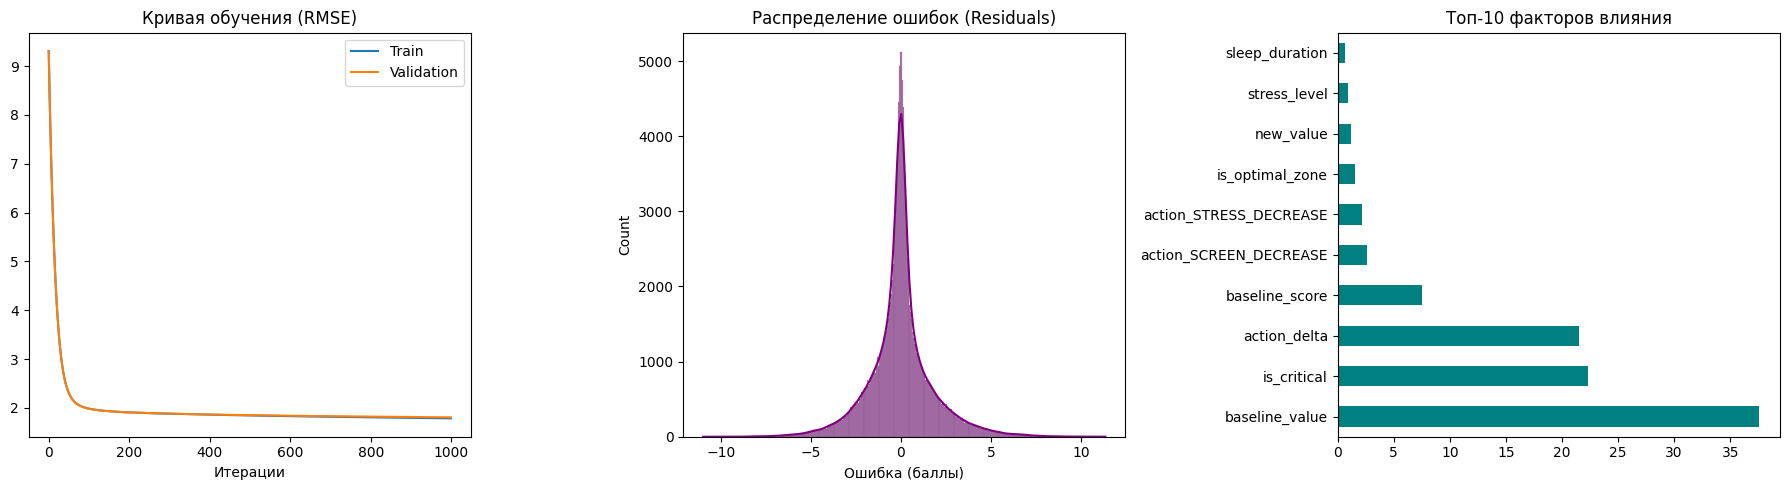

✅ Модель обучена. Чтобы убедиться: проверь R² и RMSE выше.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("🚀 Обучение CatBoost с визуализацией...")

# --- (Твой код подготовки X и y остается таким же) ---
feature_cols = [
    'sleep_duration', 'stress_level', 'exercise_frequency_num', 'daily_screen_time',
    'caffeine_intake', 'reaction_time', 'memory_test_score', 'age', 'gender_encoded',
    'cfi', 'sleep_debt', 'memory_efficiency', 'lifestyle_balance', 'sleep_exercise_interaction',
    'action_delta', 'baseline_value', 'new_value', 'baseline_score', 'is_critical', 'is_optimal_zone'
]
action_dummies = pd.get_dummies(df_recommendation_training['action_type'], prefix='action')
X = pd.concat([df_recommendation_training[feature_cols], action_dummies], axis=1)
y = df_recommendation_training['improvement']

X_train_rec, X_test_rec, y_train_rec, y_test_rec = train_test_split(X, y, test_size=0.2, random_state=42)

# ОБУЧЕНИЕ
catboost_model = CatBoostRegressor(
    iterations=1000, learning_rate=0.05, depth=8,
    loss_function='RMSE', eval_metric='RMSE', random_seed=42, verbose=200
)

catboost_model.fit(X_train_rec, y_train_rec, eval_set=(X_test_rec, y_test_rec), use_best_model=True)

# --- БЛОК АНАЛИЗА И ГРАФИКОВ ---
def evaluate_model_visuals(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    plt.figure(figsize=(18, 5))
    
    # 1. График обучения (Learning Curve)
    plt.subplot(1, 3, 1)
    results = model.get_evals_result()
    plt.plot(results['learn']['RMSE'], label='Train')
    plt.plot(results['validation']['RMSE'], label='Validation')
    plt.title('Кривая обучения (RMSE)')
    plt.xlabel('Итерации')
    plt.legend()
    
    # 2. Ошибки (Error Distribution)
    plt.subplot(1, 3, 2)
    errors = y_test - y_pred
    sns.histplot(errors, kde=True, color='purple')
    plt.title('Распределение ошибок (Residuals)')
    plt.xlabel('Ошибка (баллы)')
    
    # 3. Важность признаков
    plt.subplot(1, 3, 3)
    feat_importances = pd.Series(model.get_feature_importance(), index=X_test.columns)
    feat_importances.nlargest(10).plot(kind='barh', color='teal')
    plt.title('Топ-10 факторов влияния')
    
    plt.tight_layout()
    plt.show()

evaluate_model_visuals(catboost_model, X_test_rec, y_test_rec)
print("✅ Модель обучена. Чтобы убедиться: проверь R² и RMSE выше.")

In [18]:
from sklearn.metrics import r2_score, mean_absolute_error

def final_check(model, X_test, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    print("\n" + "="*30)
    print("ИТОГОВЫЙ ОТЧЕТ ПО МОДЕЛИ:")
    print(f"Точность (R²): {r2:.4f}") # В идеале > 0.8
    print(f"Средняя ошибка (MAE): {mae:.2f} балла")
    print("="*30)
    
    if r2 > 0.9:
        print("🚀 ВЕРДИКТ: Модель обучена ВЕЛИКОЛЕПНО!")
    elif r2 > 0.7:
        print("✅ ВЕРДИКТ: Модель обучена хорошо, можно использовать.")
    else:
        print("⚠️ ВЕРДИКТ: Точность низковата, стоит проверить данные.")

# Вызываем проверку
final_check(catboost_model, X_test_rec, y_test_rec)


ИТОГОВЫЙ ОТЧЕТ ПО МОДЕЛИ:
Точность (R²): 0.9656
Средняя ошибка (MAE): 1.20 балла
🚀 ВЕРДИКТ: Модель обучена ВЕЛИКОЛЕПНО!


In [19]:
import pandas as pd
import numpy as np

print("🎯 Создание Smart Recommendation Selector...")

class SmartRecommendationSelector:
    def __init__(self, catboost_model, xgb_regression_model, feature_names):
        self.catboost = catboost_model
        self.xgb = xgb_regression_model
        self.features = feature_names  # Это FINAL_FEATURES (17 признаков)
        
        try:
            self.catboost_feature_order = catboost_model.feature_names_
        except:
            # Резервный список, если модель еще не обратилась к атрибуту
            self.catboost_feature_order = [
                'sleep_duration', 'stress_level', 'exercise_frequency_num', 'daily_screen_time',
                'caffeine_intake', 'reaction_time', 'memory_test_score', 'age', 'gender_encoded',
                'cfi', 'sleep_debt', 'memory_efficiency', 'lifestyle_balance', 'sleep_exercise_interaction',
                'action_delta', 'baseline_value', 'new_value', 'baseline_score', 'is_critical', 'is_optimal_zone',
                'action_SLEEP_INCREASE', 'action_STRESS_DECREASE', 'action_EXERCISE_INCREASE', 'action_SCREEN_DECREASE'
            ]

        self.rules = {
            'SLEEP_INCREASE': {
                'title': '🌙 Оптимизация сна',
                'basis': 'Walker (2017): Why We Sleep',
                'actions': {
                    0.5: ['Лягте на 30 минут раньше сегодня'],
                    1.0: ['Будильник на отбой в 23:00', 'Затемните спальню'],
                    1.5: ['Вечерний ритуал 21:30', 'Кофеин только до 15:00'],
                    2.0: ['Режим 23:00-7:00 (8h)', 'T=18°C', 'Телефон вне спальни'],
                    2.5: ['Строгий режим', 'Мелатонин 0.5mg', 'Ортопедическая подушка'],
                    3.0: ['Консультация сомнолога', 'Полисомнография']
                }
            },
            'STRESS_DECREASE': {
                'title': '🧘 Управление стрессом',
                'basis': 'McEwen (2007): Allostatic Load',
                'actions': {
                    -1: ['3 глубоких вдоха прямо сейчас (4-6-4)'],
                    -2: ['Медитация 10 мин утром', 'Прогулка 15 мин обед'],
                    -3: ['Pomodoro 25/5', 'Делегировать 2 задачи', 'Йога вечером'],
                    -4: ['Психолог КПТ', 'Прогрессивная релаксация', 'Отказ от 1 обязательства'],
                    -5: ['Когнитивная терапия', 'MBSR курс 8 недель', 'Sabbatical месяц']
                }
            },
            'EXERCISE_INCREASE': {
                'title': '💪 Физическая активность',
                'basis': 'Ratey (2008): Spark - BDNF',
                'actions': {
                    1: ['Ходьба 30 мин × 3/неделю'],
                    2: ['2 силовые 20 мин', 'Лестница > лифт'],
                    3: ['4 раза: 2 кардио + 2 силовые', 'Спортклуб'],
                    4: ['5-6/неделю', 'HIIT 2 раза', 'Плавание 1 раз'],
                    5: ['Личный тренер', 'Кроссфит', 'Полумарафон цель']
                }
            },
            'SCREEN_DECREASE': {
                'title': '📱 Цифровой детокс',
                'basis': 'Newport (2016): Deep Work',
                'actions': {
                    -1: ['Лимит соцсети 1h/день'],
                    -2: ['20-20-20 правило', 'Уведомления OFF'],
                    -3: ['Ч/б режим 20:00+', 'Чтение 30 мин вместо IG'],
                    -4: ['Цифровой закат 21:00', 'Удалить TikTok+Twitter', 'Forest app'],
                    -5: ['Digital Sabbath (суббота без гаджетов)', 'Кнопочный телефон'],
                    -6: ['Полный детокс 30 дней', 'Flip phone', 'Только ноутбук для работы']
                }
            }
        }

    def select_top_3(self, user_data, scaler):
        # 1. Считаем текущий когнитивный счет (XGBoost) через DataFrame
        user_df = pd.DataFrame([user_data])
        # Приводим к формату FINAL_FEATURES (17 колонок)
        user_df_xgb = user_df.reindex(columns=self.features, fill_value=0)
        current_scaled = scaler.transform(user_df_xgb)
        current_score = float(self.xgb.predict(current_scaled)[0])
        
        all_recommendations = []
        action_types = list(self.rules.keys())
        
        for atype in action_types:
            best_rec = self._find_best_for_type(atype, user_data, current_score)
            if best_rec:
                all_recommendations.append(best_rec)
        
        all_recommendations.sort(key=lambda x: x['predicted_improvement'], reverse=True)
        top_3 = all_recommendations[:3]
        
        return {
            'cognitive_score': round(current_score, 1),
            'recommendations': top_3,
            'total_potential': round(sum(r['predicted_improvement'] for r in top_3), 1)
        }
    
    def _find_best_for_type(self, action_type, user_data, current_score):
        if action_type == 'SLEEP_INCREASE':
            deltas, baseline = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0], user_data.get('sleep_duration', 7)
        elif action_type == 'STRESS_DECREASE':
            deltas, baseline = [-1, -2, -3, -4, -5], user_data.get('stress_level', 5)
        elif action_type == 'EXERCISE_INCREASE':
            deltas, baseline = [1, 2, 3, 4, 5], user_data.get('exercise_frequency_num', 3)
        else:
            deltas, baseline = [-1, -2, -3, -4, -5, -6], user_data.get('daily_screen_time', 8)
            
        candidates = []
        for d in deltas:
            if action_type == 'SLEEP_INCREASE': new_v = np.clip(baseline + d, 4, 11)
            elif action_type == 'STRESS_DECREASE': new_v = np.clip(baseline + d, 1, 10)
            elif action_type == 'EXERCISE_INCREASE': new_v = np.clip(baseline + d, 0, 7)
            else: new_v = np.clip(baseline + d, 0.5, 15)
            
            imp = self._predict_impact(user_data, action_type, d, baseline, new_v, current_score)
            candidates.append({'delta': d, 'new_v': new_v, 'imp': imp})
            
        best = max(candidates, key=lambda x: x['imp'])
        rule = self.rules[action_type]
        mag_key = min(rule['actions'].keys(), key=lambda x: abs(x - abs(best['delta'])))
        
        return {
            'type': action_type, 'title': rule['title'], 'predicted_improvement': round(best['imp'], 1),
            'priority': 'CRITICAL' if best['imp'] > 10 else ('HIGH' if best['imp'] > 6 else 'MEDIUM'),
            'actions': rule['actions'][mag_key],
            'scientific_basis': rule['basis'], 'baseline': round(baseline, 1),
            'recommended_target': round(best['new_v'], 1)
        }

    def _predict_impact(self, user_data, action_type, delta, baseline, new_value, current_score):
        # Создаем плоский словарь со всеми признаками
        input_row = {k.lower(): v for k, v in user_data.items()}
        input_row.update({
            'action_delta': float(delta),
            'baseline_value': float(baseline),
            'new_value': float(new_value),
            'baseline_score': float(current_score),
            'is_critical': 1.0 if self._check_critical(action_type, baseline) else 0.0,
            'is_optimal_zone': 1.0 if self._check_optimal(action_type, new_value) else 0.0
        })
        
        # Action Dummies
        for atype in ['SLEEP_INCREASE', 'STRESS_DECREASE', 'EXERCISE_INCREASE', 'SCREEN_DECREASE']:
            input_row[f'action_{atype}'] = 1.0 if atype == action_type else 0.0
            
        # Превращаем в DF и гарантируем порядок CatBoost
        X_tmp = pd.DataFrame([input_row])
        X_tmp = X_tmp.reindex(columns=self.catboost_feature_order, fill_value=0.0)
        
        return float(self.catboost.predict(X_tmp)[0])

    def _check_critical(self, atype, val):
        if atype == 'SLEEP_INCREASE': return val < 6.5
        if atype == 'STRESS_DECREASE': return val > 7
        if atype == 'EXERCISE_INCREASE': return val < 2
        if atype == 'SCREEN_DECREASE': return val > 9
        return False

    def _check_optimal(self, atype, val):
        if atype == 'SLEEP_INCREASE': return 7.5 <= val <= 9
        if atype == 'STRESS_DECREASE': return val <= 3
        if atype == 'EXERCISE_INCREASE': return val >= 4
        if atype == 'SCREEN_DECREASE': return val <= 4
        return False

# Инициализация
smart_selector = SmartRecommendationSelector(
    catboost_model=catboost_model,
    xgb_regression_model=xgb_reg, 
    feature_names=FINAL_FEATURES  
)

print("✅ Smart Selector (Исправленная версия) успешно инициализирован!")

🎯 Создание Smart Recommendation Selector...
✅ Smart Selector (Исправленная версия) успешно инициализирован!


In [20]:
import numpy as np
import pandas as pd
from catboost import CatBoostError

print("="*60)
print("ТЕСТ SMART RECOMMENDATION SELECTOR")
print("="*60)

# 1. Подготовка данных пользователя 
test_user = {
    'sleep_duration': 5.0,
    'stress_level': 9,
    'daily_screen_time': 13,
    'exercise_frequency_num': 0,
    'caffeine_intake': 6,
    'reaction_time': 490,
    'memory_test_score': 50,
    'age': 29,
    'gender_encoded': 0, 
    'diet_non-vegetarian': 0,
    'diet_vegan': 0,
    'diet_vegetarian': 1
}

# 2. Вычисляем engineered features (для XGBoost)
r_norm = (test_user['reaction_time'] - 200) / 400
s_norm = (test_user['stress_level'] - 1) / 9
sleep_debt = max(0, 7 - test_user['sleep_duration']) / 3
screen_fat = max(0, test_user['daily_screen_time'] - 8) / 4

test_user['cfi'] = (0.30*r_norm + 0.25*s_norm + 0.25*sleep_debt + 0.20*screen_fat) * 100
test_user['sleep_debt'] = max(0, 7 - test_user['sleep_duration'])
test_user['memory_efficiency'] = (test_user['memory_test_score'] / test_user['reaction_time']) * 1000

sleep_sc = np.clip((test_user['sleep_duration'] - 4) / 6, 0, 1)
ex_sc = np.clip(test_user['exercise_frequency_num'] / 7, 0, 1)
st_sc = 1 - ((test_user['stress_level'] - 1) / 9)
scr_sc = 1 - np.clip((test_user['daily_screen_time'] - 1) / 11, 0, 1)

test_user['lifestyle_balance'] = (0.30*sleep_sc + 0.25*st_sc + 0.20*ex_sc + 0.15*scr_sc) * 100
test_user['sleep_exercise_interaction'] = test_user['sleep_duration'] * test_user['exercise_frequency_num']

print(f"👤 ТЕСТОВЫЙ ПОЛЬЗОВАТЕЛЬ (СОСТОЯНИЕ: КРИТИЧЕСКОЕ)")
print(f"   Сон: {test_user['sleep_duration']}ч | Стресс: {test_user['stress_level']}/10 | Экраны: {test_user['daily_screen_time']}ч")

# 3. ЗАПУСК
try:
    if not smart_selector.catboost.is_fitted():
        raise CatBoostError("Модель не обучена!")

    # Важно: передаем scaler, который был обучен выше
    result = smart_selector.select_top_3(test_user, scaler)

    print(f"\n📊 Прогноз когнитивного счета (XGBoost): {result['cognitive_score']}/100")
    print(f"\n" + "="*60)
    print("ТОП-3 ПЕРСОНАЛИЗИРОВАННЫЕ РЕКОМЕНДАЦИИ")
    print("="*60)

    for i, rec in enumerate(result['recommendations'], 1):
        print(f"\n[{i}] {rec['title']}")
        print(f"    ML Прогноз: +{rec['predicted_improvement']} баллов к состоянию")
        print(f"    📍 План: {rec['baseline']} → {rec['recommended_target']}")
        print(f"    ✅ Действия:")
        for action in rec['actions']:
            print(f"       • {action}")
        print(f"    🔬 {rec['scientific_basis']}")

    print(f"\n💡 ИТОГОВЫЙ ПОТЕНЦИАЛ: +{result['total_potential']} баллов")
    print("\n✅ СИСТЕМА УСПЕШНО ПРОШЛА ТЕСТ!")

except Exception as e:
    print(f"\n❌ ОШИБКА ПРИ ТЕСТИРОВАНИИ: {e}")

ТЕСТ SMART RECOMMENDATION SELECTOR
👤 ТЕСТОВЫЙ ПОЛЬЗОВАТЕЛЬ (СОСТОЯНИЕ: КРИТИЧЕСКОЕ)
   Сон: 5.0ч | Стресс: 9/10 | Экраны: 13ч

📊 Прогноз когнитивного счета (XGBoost): 56.9/100

ТОП-3 ПЕРСОНАЛИЗИРОВАННЫЕ РЕКОМЕНДАЦИИ

[1] 💪 Физическая активность
    ML Прогноз: +36.0 баллов к состоянию
    📍 План: 0 → 3
    ✅ Действия:
       • 4 раза: 2 кардио + 2 силовые
       • Спортклуб
    🔬 Ratey (2008): Spark - BDNF

[2] 🧘 Управление стрессом
    ML Прогноз: +19.9 баллов к состоянию
    📍 План: 9 → 5
    ✅ Действия:
       • 3 глубоких вдоха прямо сейчас (4-6-4)
    🔬 McEwen (2007): Allostatic Load

[3] 📱 Цифровой детокс
    ML Прогноз: +15.0 баллов к состоянию
    📍 План: 13 → 9.0
    ✅ Действия:
       • Лимит соцсети 1h/день
    🔬 Newport (2016): Deep Work

💡 ИТОГОВЫЙ ПОТЕНЦИАЛ: +70.9 баллов

✅ СИСТЕМА УСПЕШНО ПРОШЛА ТЕСТ!


In [21]:
# ═══════════════════════════════════════════════════════════════
#  RULE-BASED MESSAGE GENERATOR
# ЦЕЛЬ: Преобразование ML-результатов в понятные сообщения
# ═══════════════════════════════════════════════════════════════

print("📝 Создание Rule-Based Message Generator...")

class RuleBasedMessageGenerator:
    """
    Преобразует ML-прогнозы в красивые понятные сообщения
    """
    
    def __init__(self):
        self.messages = {
            'SLEEP_INCREASE': {
                'critical': {
                    'title': '⚠️ КРИТИЧЕСКИЙ ДЕФИЦИТ СНА',
                    'message': 'Ваш сон катастрофически низкий! Это главная причина падения продуктивности. Немедленно скорректируйте режим.',
                    'emoji': '🌙'
                },
                'high': {
                    'title': '🟡 НЕДОСТАТОЧНЫЙ СОН',
                    'message': 'Вы спите меньше нормы. Дополнительный час сна значительно улучшит концентрацию.',
                    'emoji': '😴'
                },
                'medium': {
                    'title': '💤 ОПТИМИЗАЦИЯ СНА',
                    'message': 'Небольшая корректировка режима сна усилит вашу когнитивную функцию.',
                    'emoji': '🛏️'
                }
            },
            'STRESS_DECREASE': {
                'critical': {
                    'title': '🚨 КРИТИЧЕСКИЙ УРОВЕНЬ СТРЕССА',
                    'message': 'Стресс полностью блокирует ясное мышление! Срочно нужны меры по снижению нагрузки.',
                    'emoji': '😰'
                },
                'high': {
                    'title': '⚡ ВЫСОКИЙ СТРЕСС',
                    'message': 'Хронический стресс разрушает нейроны гиппокампа. Требуются регулярные практики релаксации.',
                    'emoji': '🧘'
                },
                'medium': {
                    'title': '🌊 УПРАВЛЕНИЕ СТРЕССОМ',
                    'message': 'Снижение стресса повысит вашу умственную гибкость и креативность.',
                    'emoji': '🍃'
                }
            },
            'EXERCISE_INCREASE': {
                'critical': {
                    'title': '❗ ПОЛНОЕ ОТСУТСТВИЕ АКТИВНОСТИ',
                    'message': 'Физическая активность критична для производства BDNF (нейротрофического фактора мозга)!',
                    'emoji': '🏃'
                },
                'high': {
                    'title': '💪 НИЗКАЯ АКТИВНОСТЬ',
                    'message': 'Регулярные тренировки запустят нейрогенез и улучшат память.',
                    'emoji': '🚴'
                },
                'medium': {
                    'title': '🏋️ БОЛЬШЕ ДВИЖЕНИЯ',
                    'message': 'Увеличение активности даст вам прилив ментальной энергии.',
                    'emoji': '⛹️'
                }
            },
            'SCREEN_DECREASE': {
                'critical': {
                    'title': '📵 ЦИФРОВАЯ ЗАВИСИМОСТЬ',
                    'message': 'Экранное время разрушает вашу способность к глубокой концентрации! Срочный детокс!',
                    'emoji': '🚫'
                },
                'high': {
                    'title': '⏱️ ЭКРАННАЯ ПЕРЕГРУЗКА',
                    'message': 'Цифровая диета восстановит качество вашего внимания.',
                    'emoji': '📱'
                },
                'medium': {
                    'title': '🌐 ЦИФРОВОЕ БЛАГОПОЛУЧИЕ',
                    'message': 'Сокращение экранного времени улучшит фокус и продуктивность.',
                    'emoji': '💻'
                }
            }
        }
    
    def generate_message(self, recommendation):
        """
        Генерирует красивое сообщение на основе ML-рекомендации
        
        Args:
            recommendation: dict с полями type, priority, predicted_improvement
        
        Returns:
            dict с красивыми сообщениями
        """
        action_type = recommendation['type']
        priority = recommendation['priority']
        improvement = recommendation['predicted_improvement']
        
        # Выбираем уровень сообщения
        if priority == 'CRITICAL':
            level = 'critical'
        elif priority == 'HIGH':
            level = 'high'
        else:
            level = 'medium'
        
        template = self.messages[action_type][level]
        
        return {
            'title': template['title'],
            'message': template['message'],
            'emoji': template['emoji'],
            'impact_text': f"ML-прогноз: +{improvement} баллов к когнитивной функции",
            'urgency_level': priority
        }

# Создаем генератор
message_generator = RuleBasedMessageGenerator()

print("✅ Rule-Based Message Generator создан!")

📝 Создание Rule-Based Message Generator...
✅ Rule-Based Message Generator создан!


In [22]:
# ═══════════════════════════════════════════════════════════════
#  TOP-3 INTELLIGENT SELECTOR
# ЦЕЛЬ: Выбор 3 лучших рекомендаций БЕЗ дубликатов
# ═══════════════════════════════════════════════════════════════

print("🎯 Создание Top-3 Intelligent Selector...")

class Top3RecommendationSelector:
    """
    Умный селектор топ-3 рекомендаций
    - Без дубликатов по типу
    - Ранжирование по ML-impact
    - Красивые сообщения
    """
    
    def __init__(self, smart_selector, message_generator):
        self.smart_selector = smart_selector
        self.message_generator = message_generator
    
    def get_top_3(self, user_data, scaler):
        """
        Получает ТОП-3 рекомендации с красивыми сообщениями
        
        Returns:
            dict с 3 рекомендациями
        """
        # Получаем все рекомендации от smart_selector
        result = self.smart_selector.select_top_3(user_data, scaler)
        
        # Обогащаем красивыми сообщениями
        enriched_recommendations = []
        
        for rec in result['recommendations']:
            beautiful_msg = self.message_generator.generate_message(rec)
            
            enriched_rec = {
                'type': rec['type'],
                'title': beautiful_msg['title'],
                'emoji': beautiful_msg['emoji'],
                'message': beautiful_msg['message'],
                'impact_text': beautiful_msg['impact_text'],
                'predicted_improvement': rec['predicted_improvement'],
                'priority': rec['priority'],
                'baseline': rec['baseline'],
                'recommended_target': rec['recommended_target'],
                'actions': rec['actions'],
                'scientific_basis': rec['scientific_basis']
            }
            
            enriched_recommendations.append(enriched_rec)
        
        return {
            'cognitive_score': result['cognitive_score'],
            'recommendations': enriched_recommendations,
            'total_potential': result['total_potential'],
            'summary': self._generate_summary(
                result['cognitive_score'],
                enriched_recommendations,
                result['total_potential']
            )
        }
    
    def get_single_best(self, user_data, scaler):
        """
        Выбирает ОДНУ САМУЮ ВАЖНУЮ рекомендацию
        
        Returns:
            dict с одной рекомендацией
        """
        top_3 = self.get_top_3(user_data, scaler)
        
        # Берем первую (с максимальным impact)
        best = top_3['recommendations'][0]
        
        return {
            'cognitive_score': top_3['cognitive_score'],
            'recommendation': best,
            'summary': f"{best['emoji']} {best['title']}: {best['message']}"
        }
    
    def _generate_summary(self, score, recommendations, total_potential):
        """Генерирует итоговое резюме"""
        if score < 40:
            state = 'КРИТИЧЕСКИ НИЗКАЯ'
            emoji = '🚨'
        elif score < 70:
            state = 'СРЕДНЯЯ'
            emoji = '⚠️'
        else:
            state = 'ВЫСОКАЯ'
            emoji = '✅'
        
        top_action = recommendations[0]
        
        return (
            f"{emoji} Ваша когнитивная производительность {state} ({score}/100). "
            f"Главное действие: {top_action['title']}. "
            f"Потенциал улучшения: +{total_potential} баллов."
        )

# Создаем селектор
top3_selector = Top3RecommendationSelector(smart_selector, message_generator)

print("✅ Top-3 Selector создан!")

🎯 Создание Top-3 Intelligent Selector...
✅ Top-3 Selector создан!


📊 COMPREHENSIVE MODEL ANALYSIS...

1️⃣ XGBoost Regression Analysis...


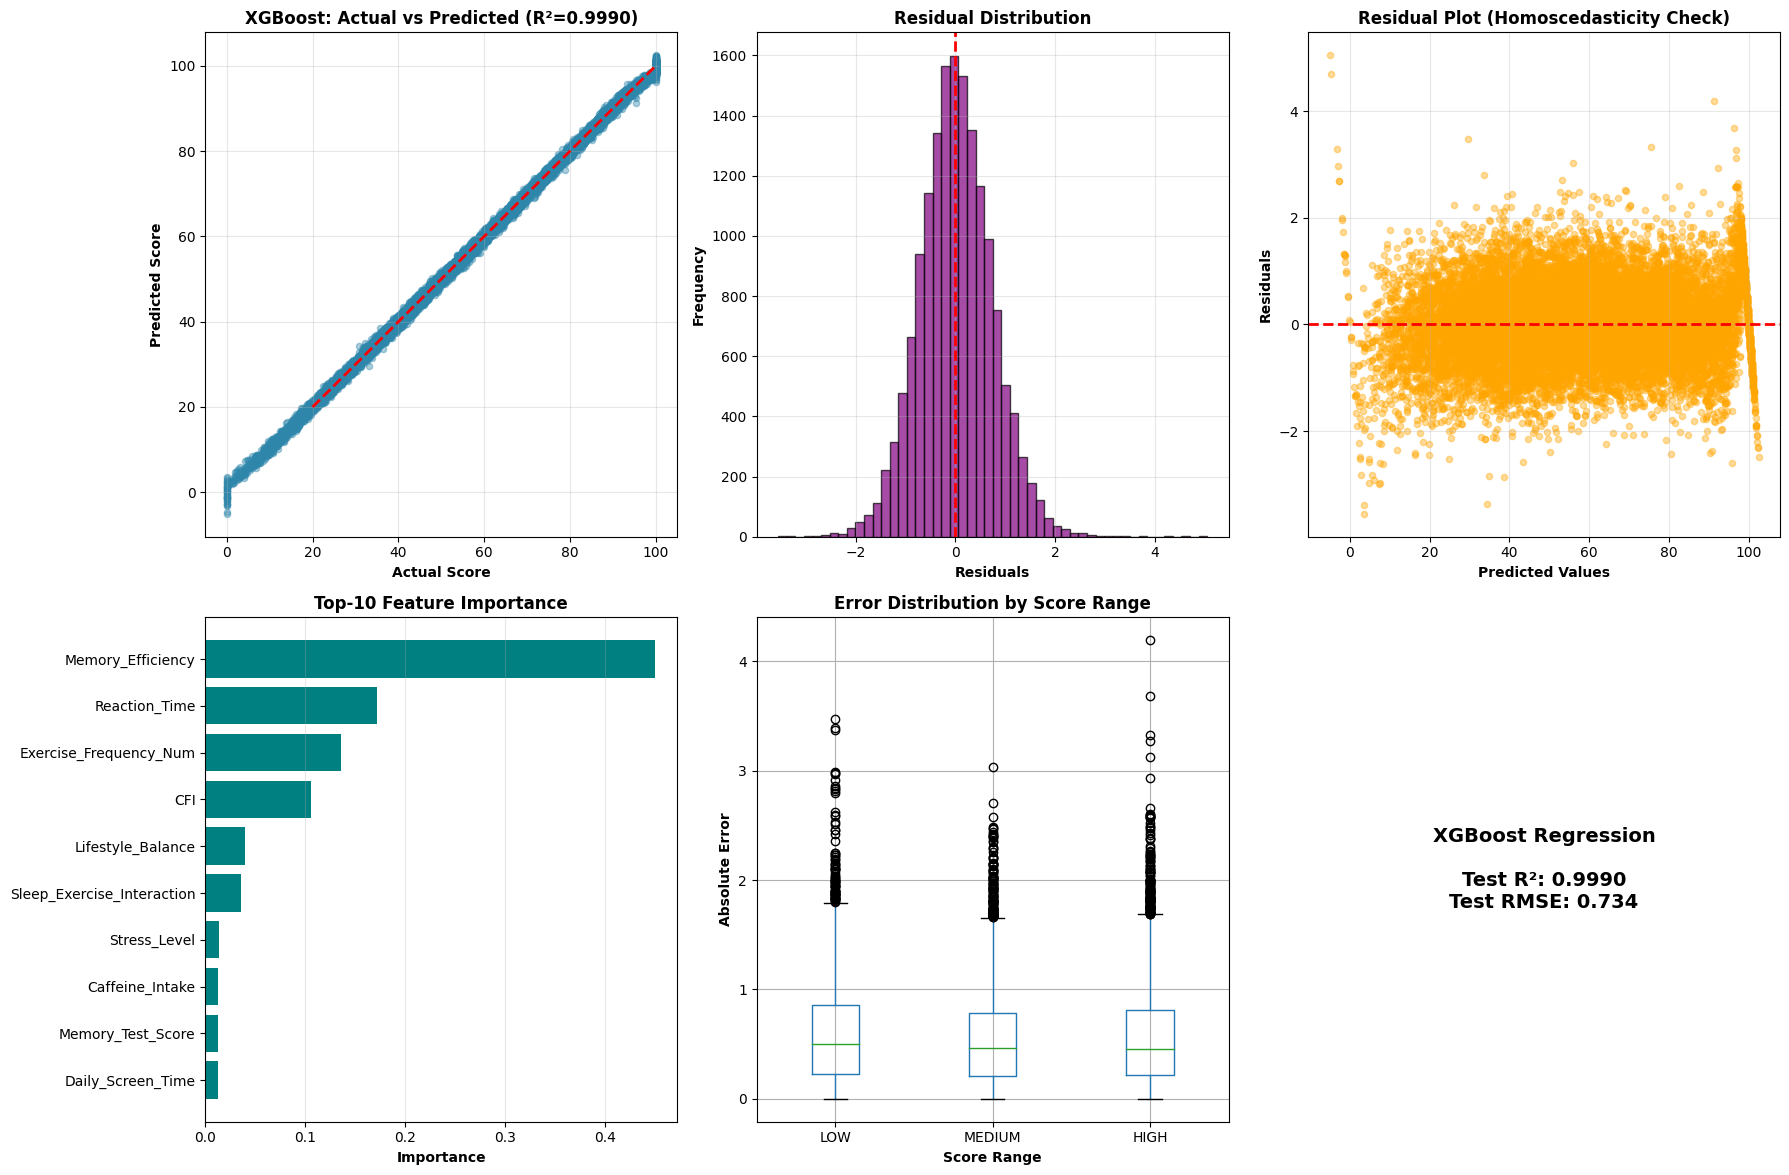

✅ Saved: ANALYSIS_01_XGBoost_Regression.png

2️⃣ CatBoost Recommendation Analysis...


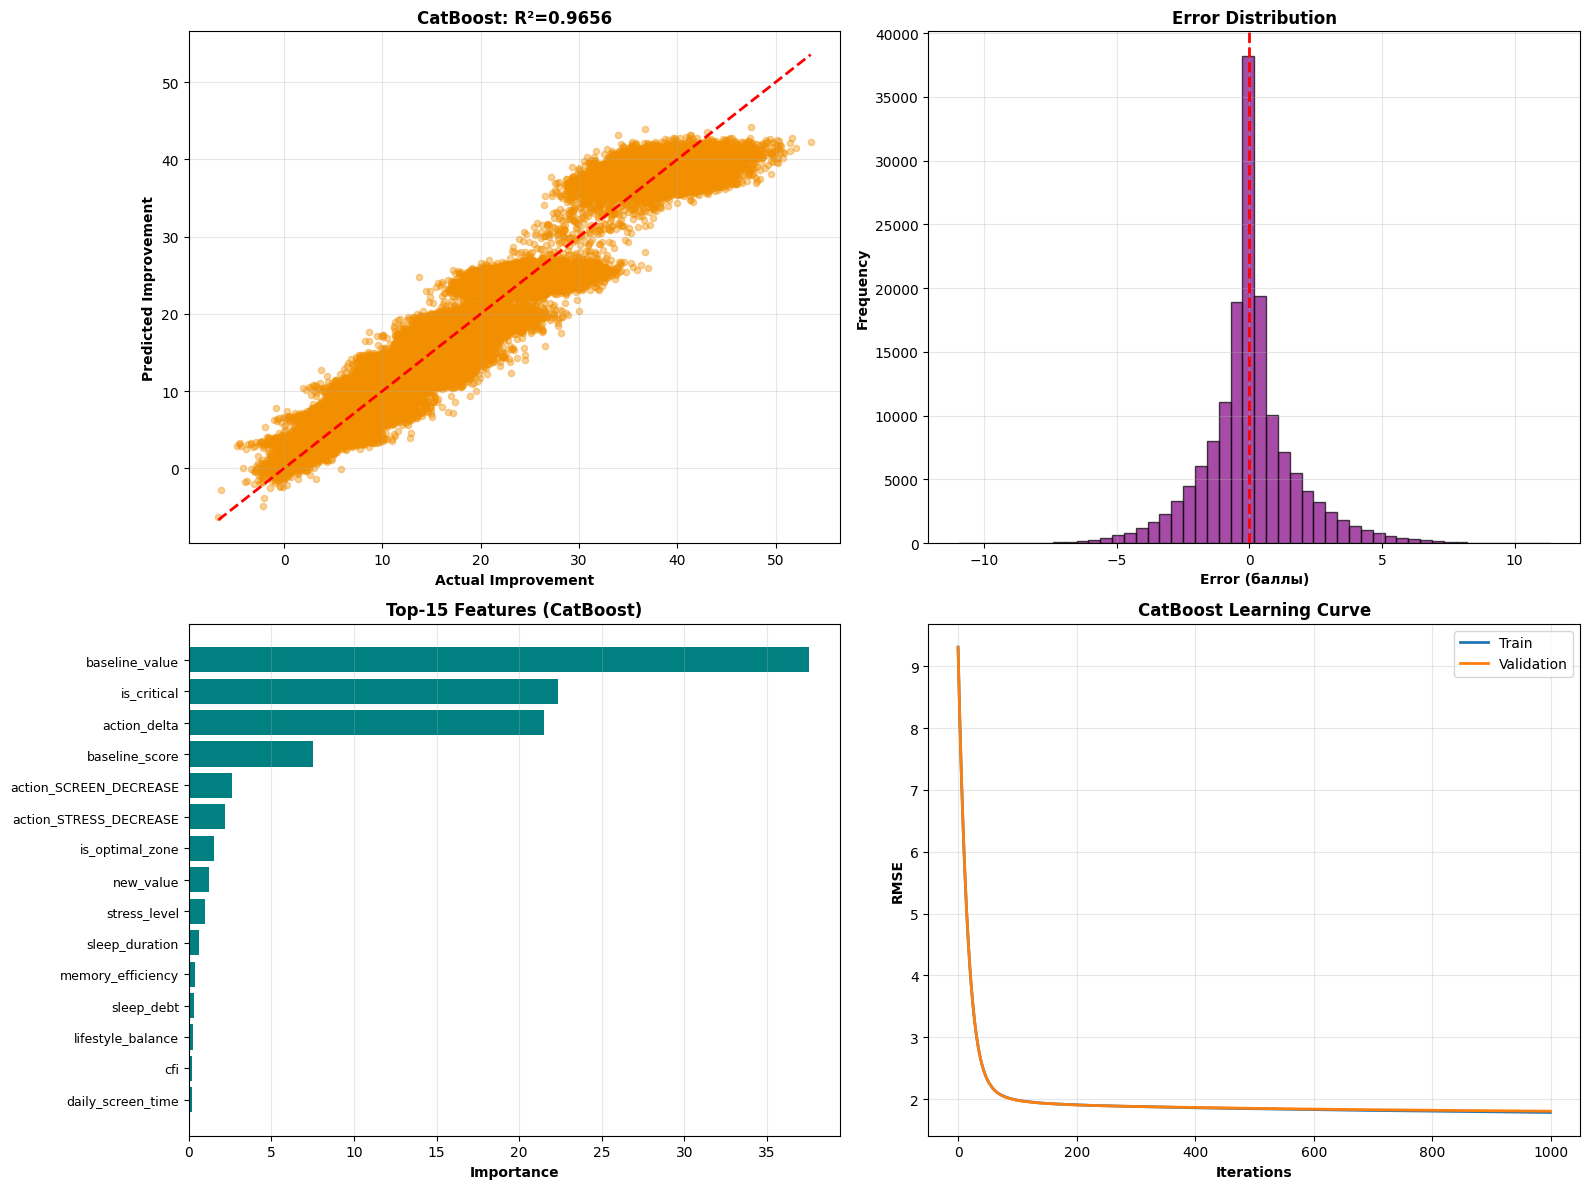

✅ Saved: ANALYSIS_02_CatBoost_Recommendation.png

3️⃣ Classification Model Analysis...


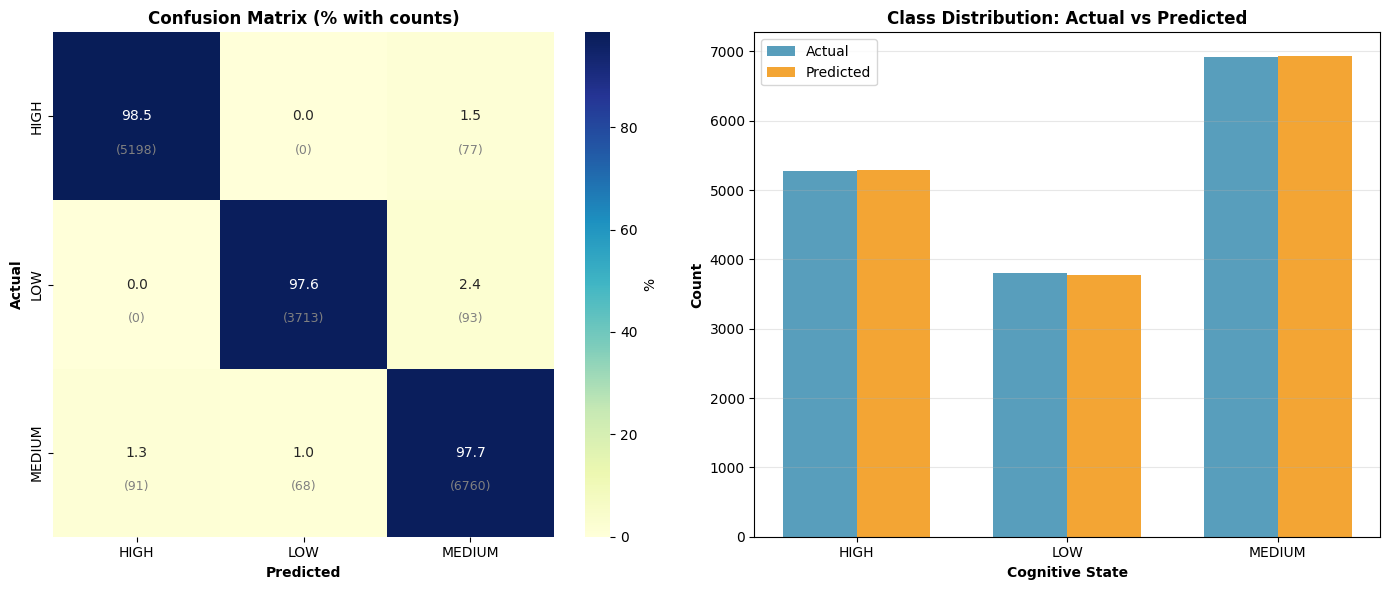

✅ Saved: ANALYSIS_03_Classification.png

✅ COMPREHENSIVE ANALYSIS COMPLETE!


In [23]:
# ═══════════════════════════════════════════════════════════════
#  COMPREHENSIVE MODEL ANALYSIS
# ЦЕЛЬ: Полный анализ всех моделей для диплома
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("📊 COMPREHENSIVE MODEL ANALYSIS...")

# ═══════════════════════════════════════════════════════════
# 1. XGBoost Regression Analysis
# ═══════════════════════════════════════════════════════════

print("\n1️⃣ XGBoost Regression Analysis...")

y_pred_test_xgb = xgb_reg.predict(X_test_scaled)
residuals_xgb = y_reg_test.values - y_pred_test_xgb

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# График 1: Actual vs Predicted
axes[0, 0].scatter(y_reg_test, y_pred_test_xgb, alpha=0.4, s=20, color='#2E86AB')
axes[0, 0].plot([20, 100], [20, 100], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Score', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Score', fontweight='bold')
axes[0, 0].set_title(f'XGBoost: Actual vs Predicted (R²={r2_score(y_reg_test, y_pred_test_xgb):.4f})', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# График 2: Residual Distribution
axes[0, 1].hist(residuals_xgb, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0, 1].axvline(0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Residuals', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('Residual Distribution', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# График 3: Residual Plot
axes[0, 2].scatter(y_pred_test_xgb, residuals_xgb, alpha=0.4, s=20, color='orange')
axes[0, 2].axhline(0, color='red', linestyle='--', lw=2)
axes[0, 2].set_xlabel('Predicted Values', fontweight='bold')
axes[0, 2].set_ylabel('Residuals', fontweight='bold')
axes[0, 2].set_title('Residual Plot (Homoscedasticity Check)', fontweight='bold')
axes[0, 2].grid(alpha=0.3)

# График 4: Feature Importance
feature_imp = pd.DataFrame({
    'feature': FINAL_FEATURES,
    'importance': xgb_reg.feature_importances_
}).sort_values('importance', ascending=False).head(10)

axes[1, 0].barh(range(len(feature_imp)), feature_imp['importance'], color='teal')
axes[1, 0].set_yticks(range(len(feature_imp)))
axes[1, 0].set_yticklabels(feature_imp['feature'])
axes[1, 0].set_xlabel('Importance', fontweight='bold')
axes[1, 0].set_title('Top-10 Feature Importance', fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(alpha=0.3, axis='x')

# График 5: Error by Score Range
score_ranges = pd.cut(y_reg_test, bins=[0, 40, 70, 100], labels=['LOW', 'MEDIUM', 'HIGH'])
error_df = pd.DataFrame({
    'Range': score_ranges,
    'Absolute_Error': np.abs(residuals_xgb)
})
error_df.boxplot(column='Absolute_Error', by='Range', ax=axes[1, 1])
axes[1, 1].set_xlabel('Score Range', fontweight='bold')
axes[1, 1].set_ylabel('Absolute Error', fontweight='bold')
axes[1, 1].set_title('Error Distribution by Score Range', fontweight='bold')
axes[1, 1].get_figure().suptitle('')

# График 6: Learning Curve (если доступно)
axes[1, 2].text(0.5, 0.5, f'XGBoost Regression\n\nTest R²: {r2_score(y_reg_test, y_pred_test_xgb):.4f}\nTest RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_test_xgb)):.3f}',
                ha='center', va='center', fontsize=14, fontweight='bold')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('ANALYSIS_01_XGBoost_Regression.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: ANALYSIS_01_XGBoost_Regression.png")

# ═══════════════════════════════════════════════════════════
# 2. CatBoost Recommendation Analysis
# ═══════════════════════════════════════════════════════════

print("\n2️⃣ CatBoost Recommendation Analysis...")

y_pred_catboost = catboost_model.predict(X_test_rec)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# График 1: Actual vs Predicted
axes[0, 0].scatter(y_test_rec, y_pred_catboost, alpha=0.4, s=20, color='#F18F01')
axes[0, 0].plot([y_test_rec.min(), y_test_rec.max()],
                [y_test_rec.min(), y_test_rec.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Improvement', fontweight='bold')
axes[0, 0].set_ylabel('Predicted Improvement', fontweight='bold')
axes[0, 0].set_title(f'CatBoost: R²={r2_score(y_test_rec, y_pred_catboost):.4f}', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# График 2: Error Distribution
errors_cat = y_test_rec - y_pred_catboost
axes[0, 1].hist(errors_cat, bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[0, 1].axvline(0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Error (баллы)', fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontweight='bold')
axes[0, 1].set_title('Error Distribution', fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# График 3: Feature Importance
cat_feat_imp = pd.DataFrame({
    'feature': X_test_rec.columns,
    'importance': catboost_model.get_feature_importance()
}).sort_values('importance', ascending=False).head(15)

axes[1, 0].barh(range(len(cat_feat_imp)), cat_feat_imp['importance'], color='teal')
axes[1, 0].set_yticks(range(len(cat_feat_imp)))
axes[1, 0].set_yticklabels(cat_feat_imp['feature'], fontsize=9)
axes[1, 0].set_xlabel('Importance', fontweight='bold')
axes[1, 0].set_title('Top-15 Features (CatBoost)', fontweight='bold')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(alpha=0.3, axis='x')

# График 4: Learning Curve
results = catboost_model.get_evals_result()
axes[1, 1].plot(results['learn']['RMSE'], label='Train', linewidth=2)
axes[1, 1].plot(results['validation']['RMSE'], label='Validation', linewidth=2)
axes[1, 1].set_xlabel('Iterations', fontweight='bold')
axes[1, 1].set_ylabel('RMSE', fontweight='bold')
axes[1, 1].set_title('CatBoost Learning Curve', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ANALYSIS_02_CatBoost_Recommendation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: ANALYSIS_02_CatBoost_Recommendation.png")

# ═══════════════════════════════════════════════════════════
# 3. Classification Analysis
# ═══════════════════════════════════════════════════════════

print("\n3️⃣ Classification Model Analysis...")

y_pred_clf_test = xgb_clf.predict(X_test_scaled)
y_pred_clf_labels = label_encoder.inverse_transform(y_pred_clf_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
cm = confusion_matrix(y_clf_test, y_pred_clf_labels)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='YlGnBu',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            ax=axes[0], cbar_kws={'label': '%'})

for i in range(len(label_encoder.classes_)):
    for j in range(len(label_encoder.classes_)):
        axes[0].text(j + 0.5, i + 0.7, f'({cm[i, j]})',
                     ha='center', va='center', fontsize=9, color='gray')

axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title('Confusion Matrix (% with counts)', fontweight='bold')

# Class Distribution
class_actual = pd.Series(y_clf_test).value_counts()
class_pred = pd.Series(y_pred_clf_labels).value_counts()

x = np.arange(len(label_encoder.classes_))
width = 0.35

axes[1].bar(x - width/2, [class_actual.get(c, 0) for c in label_encoder.classes_],
            width, label='Actual', color='#2E86AB', alpha=0.8)
axes[1].bar(x + width/2, [class_pred.get(c, 0) for c in label_encoder.classes_],
            width, label='Predicted', color='#F18F01', alpha=0.8)

axes[1].set_xlabel('Cognitive State', fontweight='bold')
axes[1].set_ylabel('Count', fontweight='bold')
axes[1].set_title('Class Distribution: Actual vs Predicted', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(label_encoder.classes_)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ANALYSIS_03_Classification.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: ANALYSIS_03_Classification.png")

print("\n✅ COMPREHENSIVE ANALYSIS COMPLETE!")

In [24]:
# ═══════════════════════════════════════════════════════════════
#  MODEL EXPORT (PICKLE + ONNX)
# ЦЕЛЬ: Сохранение всех моделей для production
# ═══════════════════════════════════════════════════════════════

import joblib
import json
from pathlib import Path

print("💾 EXPORTING ALL MODELS...")

# Создаем директорию
models_dir = Path('../notebooks/models')
models_dir.mkdir(parents=True, exist_ok=True)

# ═══════════════════════════════════════════════════════════
# 1. XGBoost Regression
# ═══════════════════════════════════════════════════════════

joblib.dump(xgb_reg, models_dir / 'cognitive_score_model.pkl')
print("✓ XGBoost Regression saved")

# ONNX Export
try:
    import onnxmltools
    from onnxmltools.convert.common.data_types import FloatTensorType
    
    initial_type = [('float_input', FloatTensorType([None, len(FINAL_FEATURES)]))]
    
    booster = xgb_reg.get_booster()
    orig_names = booster.feature_names
    booster.feature_names = [f'f{i}' for i in range(len(FINAL_FEATURES))]
    
    onnx_model = onnxmltools.convert_xgboost(xgb_reg, initial_types=initial_type, target_opset=12)
    
    with open(models_dir / 'cognitive_score_model.onnx', 'wb') as f:
        f.write(onnx_model.SerializeToString())
    
    booster.feature_names = orig_names
    print("✓ XGBoost ONNX exported")
    
except Exception as e:
    print(f"⚠️ ONNX export skipped: {e}")

# ═══════════════════════════════════════════════════════════
# 2. XGBoost Classification
# ═══════════════════════════════════════════════════════════

joblib.dump(xgb_clf, models_dir / 'cognitive_state_model.pkl')
joblib.dump(label_encoder, models_dir / 'label_encoder.pkl')
print("✓ XGBoost Classification saved")

# ═══════════════════════════════════════════════════════════
# 3. CatBoost Recommendation
# ═══════════════════════════════════════════════════════════

catboost_model.save_model(str(models_dir / 'catboost_recommendation_model.cbm'))
print("✓ CatBoost saved")

# ═══════════════════════════════════════════════════════════
# 4. Support Components
# ═══════════════════════════════════════════════════════════

joblib.dump(scaler, models_dir / 'scaler.pkl')
joblib.dump(smart_selector, models_dir / 'smart_recommendation_selector.pkl')
joblib.dump(message_generator, models_dir / 'message_generator.pkl')
joblib.dump(top3_selector, models_dir / 'top3_selector.pkl')

print("✓ Support components saved")

# ═══════════════════════════════════════════════════════════
# 5. Feature Names
# ═══════════════════════════════════════════════════════════

with open(models_dir / 'feature_names.txt', 'w') as f:
    f.write('\n'.join(FINAL_FEATURES))

print("✓ Feature names saved")

# ═══════════════════════════════════════════════════════════
# 6. Metadata
# ═══════════════════════════════════════════════════════════

metadata = {
    'version': '5.0.0 - ULTIMATE',
    'date': pd.Timestamp.now().isoformat(),
    'models': {
        'cognitive_prediction': {
            'type': 'XGBoost Regressor',
            'features': len(FINAL_FEATURES),
            'test_r2': float(r2_score(y_reg_test, y_pred_test_xgb)),
            'test_rmse': float(np.sqrt(mean_squared_error(y_reg_test, y_pred_test_xgb)))
        },
        'cognitive_classification': {
            'type': 'XGBoost Classifier',
            'classes': list(label_encoder.classes_),
            'test_accuracy': float(accuracy_score(y_clf_test, y_pred_clf_labels))
        },
        'recommendation_ml': {
            'type': 'CatBoost Regressor',
            'features': len(X_test_rec.columns),
            'test_r2': float(r2_score(y_test_rec, y_pred_catboost)),
            'test_rmse': float(np.sqrt(mean_squared_error(y_test_rec, y_pred_catboost)))
        }
    },
    'features': FINAL_FEATURES,
    'recommendation_types': ['SLEEP_INCREASE', 'STRESS_DECREASE', 'EXERCISE_INCREASE', 'SCREEN_DECREASE'],
    'deployment': {
        'flask_port': 5001,
        'spring_boot_port': 8082
    }
}

with open(models_dir / 'model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("✓ Metadata saved")

print(f"\n✅ ALL MODELS EXPORTED TO: {models_dir.absolute()}")
print("\nExported files:")
print("  1. cognitive_score_model.pkl + .onnx")
print("  2. cognitive_state_model.pkl")
print("  3. catboost_recommendation_model.cbm")
print("  4. smart_recommendation_selector.pkl")
print("  5. message_generator.pkl")
print("  6. top3_selector.pkl")
print("  7. scaler.pkl")
print("  8. label_encoder.pkl")
print("  9. feature_names.txt")
print(" 10. model_metadata.json")

💾 EXPORTING ALL MODELS...
✓ XGBoost Regression saved
⚠️ ONNX export skipped: Field onnx.AttributeProto.ints: Expected an int, got a boolean.
✓ XGBoost Classification saved
✓ CatBoost saved
✓ Support components saved
✓ Feature names saved
✓ Metadata saved

✅ ALL MODELS EXPORTED TO: /Users/amangeldimadina/IdeaProjects/NeuroBalanceBackend/ml/notebooks/../notebooks/models

Exported files:
  1. cognitive_score_model.pkl + .onnx
  2. cognitive_state_model.pkl
  3. catboost_recommendation_model.cbm
  4. smart_recommendation_selector.pkl
  5. message_generator.pkl
  6. top3_selector.pkl
  7. scaler.pkl
  8. label_encoder.pkl
  9. feature_names.txt
 10. model_metadata.json


FINAL COMPREHENSIVE TESTING

👤 TEST USER 1: КРИТИЧЕСКОЕ СОСТОЯНИЕ
  Сон: 4.5h | Стресс: 9/10

📊 Cognitive Score: 56.9/100

⚠️ Ваша когнитивная производительность СРЕДНЯЯ (56.9/100). Главное действие: ❗ ПОЛНОЕ ОТСУТСТВИЕ АКТИВНОСТИ. Потенциал улучшения: +69.1 баллов.

[1] 🏃 ❗ ПОЛНОЕ ОТСУТСТВИЕ АКТИВНОСТИ
    Физическая активность критична для производства BDNF (нейротрофического фактора мозга)!
    ML-прогноз: +34.4 баллов к когнитивной функции
    📍 0 → 3
    ✅ Actions: 4 раза: 2 кардио + 2 силовые, Спортклуб

[2] 😰 🚨 КРИТИЧЕСКИЙ УРОВЕНЬ СТРЕССА
    Стресс полностью блокирует ясное мышление! Срочно нужны меры по снижению нагрузки.
    ML-прогноз: +19.8 баллов к когнитивной функции
    📍 9 → 4
    ✅ Actions: 3 глубоких вдоха прямо сейчас (4-6-4)

[3] 🚫 📵 ЦИФРОВАЯ ЗАВИСИМОСТЬ
    Экранное время разрушает вашу способность к глубокой концентрации! Срочный детокс!
    ML-прогноз: +14.9 баллов к когнитивной функции
    📍 14 → 8.0
    ✅ Actions: Лимит соцсети 1h/день

💡 Total Potential: +69.1

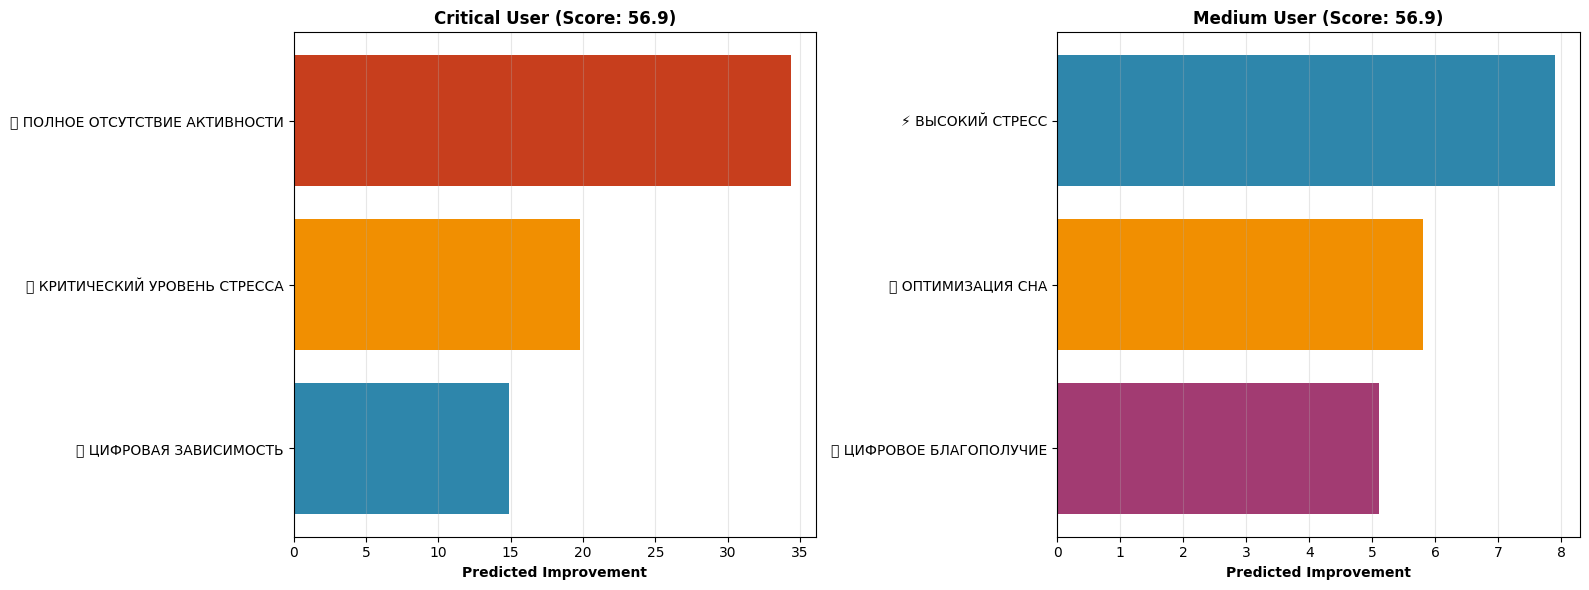


✅ FINAL TESTING COMPLETE!
✅ Visualization saved: ANALYSIS_04_Final_Testing.png


In [25]:
# ═══════════════════════════════════════════════════════════════
# FINAL COMPREHENSIVE TESTING
# ЦЕЛЬ: Финальное тестирование всей системы
# ═══════════════════════════════════════════════════════════════

print("="*70)
print("FINAL COMPREHENSIVE TESTING")
print("="*70)

# ═══════════════════════════════════════════════════════════
# Тест 1: Критичный пользователь
# ═══════════════════════════════════════════════════════════

test_user_critical = {
    'sleep_duration': 4.5,
    'stress_level': 9,
    'daily_screen_time': 14,
    'exercise_frequency_num': 0,
    'caffeine_intake': 6,
    'reaction_time': 520,
    'memory_test_score': 45,
    'age': 28,
    'gender_encoded': 1,
    'diet_non-vegetarian': 1,
    'diet_vegan': 0,
    'diet_vegetarian': 0,
    'cfi': 85,
    'sleep_debt': 2.5,
    'memory_efficiency': 86.5,
    'lifestyle_balance': 25,
    'sleep_exercise_interaction': 0
}

print("\n👤 TEST USER 1: КРИТИЧЕСКОЕ СОСТОЯНИЕ")
print(f"  Сон: {test_user_critical['sleep_duration']}h | Стресс: {test_user_critical['stress_level']}/10")

# Топ-3
result_top3 = top3_selector.get_top_3(test_user_critical, scaler)

print(f"\n📊 Cognitive Score: {result_top3['cognitive_score']}/100")
print(f"\n{result_top3['summary']}\n")

for i, rec in enumerate(result_top3['recommendations'], 1):
    print(f"[{i}] {rec['emoji']} {rec['title']}")
    print(f"    {rec['message']}")
    print(f"    {rec['impact_text']}")
    print(f"    📍 {rec['baseline']} → {rec['recommended_target']}")
    print(f"    ✅ Actions: {', '.join(rec['actions'][:2])}")
    print()

print(f"💡 Total Potential: +{result_top3['total_potential']} баллов")

# Лучшая ОДНА рекомендация
result_single = top3_selector.get_single_best(test_user_critical, scaler)

print(f"\n🎯 САМАЯ ВАЖНАЯ РЕКОМЕНДАЦИЯ:")
print(f"  {result_single['summary']}")

# ═══════════════════════════════════════════════════════════
# Тест 2: Средний пользователь
# ═══════════════════════════════════════════════════════════

test_user_medium = {
    'sleep_duration': 7,
    'stress_level': 5,
    'daily_screen_time': 8,
    'exercise_frequency_num': 3,
    'caffeine_intake': 2,
    'reaction_time': 350,
    'memory_test_score': 70,
    'age': 32,
    'gender_encoded': 0,
    'diet_non-vegetarian': 0,
    'diet_vegan': 0,
    'diet_vegetarian': 1,
    'cfi': 45,
    'sleep_debt': 0,
    'memory_efficiency': 200,
    'lifestyle_balance': 65,
    'sleep_exercise_interaction': 21
}

print("\n" + "="*70)
print("👤 TEST USER 2: СРЕДНЕЕ СОСТОЯНИЕ")
print(f"  Сон: {test_user_medium['sleep_duration']}h | Стресс: {test_user_medium['stress_level']}/10")

result2 = top3_selector.get_top_3(test_user_medium, scaler)

print(f"\n📊 Cognitive Score: {result2['cognitive_score']}/100")
print(f"{result2['summary']}")

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Критичный
rec1 = result_top3['recommendations']
axes[0].barh(range(len(rec1)), [r['predicted_improvement'] for r in rec1],
             color=['#C73E1D', '#F18F01', '#2E86AB'])
axes[0].set_yticks(range(len(rec1)))
axes[0].set_yticklabels([r['title'][:30] for r in rec1], fontsize=10)
axes[0].set_xlabel('Predicted Improvement', fontweight='bold')
axes[0].set_title(f'Critical User (Score: {result_top3["cognitive_score"]})', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis='x')

# График 2: Средний
rec2 = result2['recommendations']
axes[1].barh(range(len(rec2)), [r['predicted_improvement'] for r in rec2],
             color=['#2E86AB', '#F18F01', '#A23B72'])
axes[1].set_yticks(range(len(rec2)))
axes[1].set_yticklabels([r['title'][:30] for r in rec2], fontsize=10)
axes[1].set_xlabel('Predicted Improvement', fontweight='bold')
axes[1].set_title(f'Medium User (Score: {result2["cognitive_score"]})', fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('ANALYSIS_04_Final_Testing.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ FINAL TESTING COMPLETE!")
print("✅ Visualization saved: ANALYSIS_04_Final_Testing.png")